# File loading

In [1]:
import pandas as pd

df = pd.read_csv("fixation/18sat_fixfinal.csv")

print(df.shape)
print(df.columns.tolist())
print(df.head())
print(df.dtypes)

(463564, 29)
['RECORDING_SESSION_LABEL', 'TRIAL_INDEX', 'CURRENT_FIX_X', 'CURRENT_FIX_Y', 'CURRENT_FIX_PUPIL', 'CURRENT_FIX_DURATION', 'CURRENT_FIX_INTEREST_AREA_ID', 'CURRENT_FIX_INTEREST_AREA_LABEL', 'CURRENT_FIX_INTEREST_AREA_PIXEL_AREA', 'CURRENT_FIX_INTEREST_AREA_RUN_ID', 'CURRENT_FIX_INTEREST_AREA_DWELL_TIME', 'PREVIOUS_SAC_DIRECTION', 'PREVIOUS_SAC_ANGLE', 'PREVIOUS_SAC_AMPLITUDE', 'PREVIOUS_SAC_AVG_VELOCITY', 'PREVIOUS_SAC_CONTAINS_BLINK', 'PREVIOUS_SAC_BLINK_DURATION', 'Session_Name_', 'Trial_Index_', 'Trial_Recycled_', 'total_page', 'type', 'book_name', 'book', 'page', 'RT', 'answer', 'correct_answer', 'page_name']
  RECORDING_SESSION_LABEL  TRIAL_INDEX  CURRENT_FIX_X  CURRENT_FIX_Y  \
0                  msd001            1           59.8          125.4   
1                  msd001            1          348.7          182.0   
2                  msd001            1          630.5          400.3   
3                  msd001            1          492.0          400.2   
4      

In [2]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 463564 entries, 0 to 463563
Data columns (total 29 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   RECORDING_SESSION_LABEL               463564 non-null  str    
 1   TRIAL_INDEX                           463564 non-null  int64  
 2   CURRENT_FIX_X                         463564 non-null  float64
 3   CURRENT_FIX_Y                         463564 non-null  float64
 4   CURRENT_FIX_PUPIL                     463564 non-null  float64
 5   CURRENT_FIX_DURATION                  463564 non-null  int64  
 6   CURRENT_FIX_INTEREST_AREA_ID          251087 non-null  float64
 7   CURRENT_FIX_INTEREST_AREA_LABEL       251087 non-null  str    
 8   CURRENT_FIX_INTEREST_AREA_PIXEL_AREA  251087 non-null  float64
 9   CURRENT_FIX_INTEREST_AREA_RUN_ID      251087 non-null  float64
 10  CURRENT_FIX_INTEREST_AREA_DWELL_TIME  251087 non-null  float64
 11  PREVIOUS_SA

# Pre-processing

In [3]:
## Distinguishing between reading the passages or answering the questions

reading = df[df["type"] == "reading"].copy()
questions = df[df["type"] == "question"].copy()

In [4]:
## Get comprehension score per passage
# One row per question rather than one row per fixation
question_trials = (
    questions[
        [
            "RECORDING_SESSION_LABEL",
            "book_name",
            "page",
            "answer",
            "correct_answer"
        ]
    ]
    .drop_duplicates()
)

# Scored comprehension questions only
comprehension_questions = question_trials[
    question_trials["correct_answer"] != -99
].copy()

comprehension_questions["correct"] = (
    comprehension_questions["answer"]
    == comprehension_questions["correct_answer"]
).astype(int)

passage_comprehension = (
    comprehension_questions
    .groupby(["RECORDING_SESSION_LABEL", "book_name"])
    .agg(
        n_correct=("correct", "sum"),
        n_questions=("correct", "count"),
        comprehension_score=("correct", "mean")
    )
    .reset_index()
)

In [5]:
print(passage_comprehension.head())

  RECORDING_SESSION_LABEL  book_name  n_correct  n_questions  \
0                  msd001    dickens          3            5   
1                  msd001    flytrap          4            5   
2                  msd001     genome          4            5   
3                  msd001  northpole          4            5   
4                  msd002    dickens          3            5   

   comprehension_score  
0                  0.6  
1                  0.8  
2                  0.8  
3                  0.8  
4                  0.6  


In [6]:
## Try to get the same median score as paper to classify as high/low comprehension level

median_comprehension = passage_comprehension["comprehension_score"].median()

print("Median comprehension:", median_comprehension)


Median comprehension: 0.6


In [7]:
passage_comprehension["comprehension_level"] = (
    passage_comprehension["comprehension_score"]
    .apply(lambda x: "High" if x >= median_comprehension else "Low")
)

print(passage_comprehension.head(10))

  RECORDING_SESSION_LABEL  book_name  n_correct  n_questions  \
0                  msd001    dickens          3            5   
1                  msd001    flytrap          4            5   
2                  msd001     genome          4            5   
3                  msd001  northpole          4            5   
4                  msd002    dickens          3            5   
5                  msd002    flytrap          0            5   
6                  msd002     genome          3            5   
7                  msd002  northpole          3            5   
8                  msd003    dickens          3            5   
9                  msd003    flytrap          4            5   

   comprehension_score comprehension_level  
0                  0.6                High  
1                  0.8                High  
2                  0.8                High  
3                  0.8                High  
4                  0.6                High  
5                  0.0   

In [8]:
passage_comprehension.shape

(380, 6)

In [9]:
## Calculate overall_comprehension

overall_comprehension = (
    passage_comprehension
    .groupby("RECORDING_SESSION_LABEL")
    .agg(
        n_correct=("n_correct", "sum"),
        n_questions=("n_questions", "sum")
    )
    .reset_index()
)

overall_comprehension["comprehension_score"] = (
    overall_comprehension["n_correct"]
    / overall_comprehension["n_questions"]
)

print(overall_comprehension.head())

  RECORDING_SESSION_LABEL  n_correct  n_questions  comprehension_score
0                  msd001         15           20                 0.75
1                  msd002          9           20                 0.45
2                  msd003         13           20                 0.65
3                  msd004         12           20                 0.60
4                  msd005         15           20                 0.75


In [10]:
overall_median = overall_comprehension["comprehension_score"].median()

print("Overall comprehension median:", overall_median)

Overall comprehension median: 0.55


In [11]:
overall_comprehension["comprehension_level"] = (
   overall_comprehension["comprehension_score"]
    .apply(lambda x: "High" if x >= overall_median else "Low")
)

print(overall_comprehension.head(10))


  RECORDING_SESSION_LABEL  n_correct  n_questions  comprehension_score  \
0                  msd001         15           20                 0.75   
1                  msd002          9           20                 0.45   
2                  msd003         13           20                 0.65   
3                  msd004         12           20                 0.60   
4                  msd005         15           20                 0.75   
5                  msd007         17           20                 0.85   
6                  msd008         11           20                 0.55   
7                  msd009         12           20                 0.60   
8                  msd010          9           20                 0.45   
9                  msd011         10           20                 0.50   

  comprehension_level  
0                High  
1                 Low  
2                High  
3                High  
4                High  
5                High  
6                

In [12]:
overall_comprehension.shape

(95, 5)

# Statistical analysis

## Eye-tracking measures

Start with the measures used in the original SB-SAT paper:

* **Mean fixation duration**
  * Time spent during individual fixations.
  * Longer fixation durations can indicate greater processing demands during reading (e.g., Just & Carpenter, 1980).
  * SB-SAT found longer mean fixation durations for low compared with high passage comprehension.

* **Reading rate**
  * Overall reading speed, expressed as words per minute (WPM).
  * SB-SAT found higher reading rates for participants with higher passage comprehension.

* **Mean saccade amplitude**
  * How far the eye moves between consecutive fixations.
  * SB-SAT found larger mean saccade amplitudes for higher passage comprehension.

* **Mean pupil size**
  * Pupil dilation can be related to cognitive load (e.g., Krejtz et al., 2018).
  * However, pupil size is influenced by other factors such as luminance.
  * SB-SAT did not find significant differences in pupil size between comprehension groups.

Additional interpretable reading measures:

* **Regression rate / count**
  * Number or proportion of backward eye movements during reading.
  * Regressions can indicate rereading and increased processing demands.
  * However, regressions should not automatically be interpreted as poor comprehension:
    readers may regress to integrate information, verify something, or strategically reread
    (e.g., Booth & Weger, 2013; Raney et al., 2014).
  * Regression was suggested as a possible feature for future work in the SB-SAT paper.

* **Fixation count**
  * Number of fixations made while reading a passage.
  * Can provide an indication of the amount of visual/cognitive processing devoted to the text.
  * Should be interpreted together with reading time and fixation duration, since these measures are related.

## General interpretation

Fixation duration, fixation count, and regressions can provide indicators of
processing demands during text comprehension.

These measures should not be interpreted deterministically. For example,
more regressions do not necessarily mean poorer comprehension; they may also
reflect strategic rereading or active integration of information.

The aim is therefore to examine whether these eye-tracking measures are
**associated with passage comprehension**, rather than treating any individual
eye-tracking behaviour as evidence of poor comprehension.

## Unit of analysis: participant × passage

One row represents one participant reading one passage.

This choice aligns the eye-tracking predictors with the level at which passage
comprehension was measured in SB-SAT. Passage comprehension is a score for a
specific participant on a specific passage, so eye-tracking behaviour is aggregated
over that same participant–passage combination.

For example:

Participant 1 + Dickens  
→ eye-tracking behaviour while reading Dickens  
→ comprehension score for Dickens

Participant 1 + Flytrap  
→ eye-tracking behaviour while reading Flytrap  
→ comprehension score for Flytrap

Reasons for using participant × passage as the unit of analysis:

1. **Avoids a mismatch between local eye movements and a global outcome.**
   In the original paper, 21-fixation windows inherited the passage-level
   comprehension label. The authors acknowledge that this assumes that local
   reading behaviour reflects comprehension at the level of the whole passage.

2. **Avoids pseudo-replication.**
   Individual fixations are not independent comprehension observations.
   Comprehension was measured once for each participant–passage combination.

3. **Provides interpretable passage-level predictors.**
   Eye-tracking measures such as mean fixation duration, fixation count,
   saccade amplitude, and regression rate can be summarised for the complete
   reading of a passage and directly related to that passage's comprehension score.

4. **Fits the repeated-measures structure of the data.**
   Each participant reads multiple passages, so observations from the same
   participant are related. This can be accounted for using a mixed-effects model.

In [13]:
eye_features = (
    reading
    .groupby(["RECORDING_SESSION_LABEL", "book_name"])
    .agg(
        mean_fix_duration=("CURRENT_FIX_DURATION", "mean"),
        median_fix_duration=("CURRENT_FIX_DURATION", "median"),
        n_fixations=("CURRENT_FIX_DURATION", "count"),
        mean_saccade_amplitude=("PREVIOUS_SAC_AMPLITUDE", "mean"),
        mean_pupil_size=("CURRENT_FIX_PUPIL", "mean")
    )
    .reset_index()
)

print(eye_features.head(10))
print(eye_features.shape)

  RECORDING_SESSION_LABEL  book_name  mean_fix_duration  median_fix_duration  \
0                  msd001    dickens         182.131373                177.5   
1                  msd001    flytrap         198.790373                188.5   
2                  msd001     genome         205.161677                189.0   
3                  msd001  northpole         184.591146                178.0   
4                  msd002    dickens         234.771053                201.0   
5                  msd002    flytrap         225.617680                199.0   
6                  msd002     genome         258.632266                218.0   
7                  msd002  northpole         250.137691                210.0   
8                  msd003    dickens         267.781377                243.0   
9                  msd003    flytrap         250.510135                212.5   

   n_fixations  mean_saccade_amplitude  mean_pupil_size  
0          510                5.353921      1610.600000  
1  

In [14]:
analysis_df = eye_features.merge(
    passage_comprehension,
    on=["RECORDING_SESSION_LABEL", "book_name"],
    how="inner"
)

print(analysis_df.head(10))
print(analysis_df.shape)

  RECORDING_SESSION_LABEL  book_name  mean_fix_duration  median_fix_duration  \
0                  msd001    dickens         182.131373                177.5   
1                  msd001    flytrap         198.790373                188.5   
2                  msd001     genome         205.161677                189.0   
3                  msd001  northpole         184.591146                178.0   
4                  msd002    dickens         234.771053                201.0   
5                  msd002    flytrap         225.617680                199.0   
6                  msd002     genome         258.632266                218.0   
7                  msd002  northpole         250.137691                210.0   
8                  msd003    dickens         267.781377                243.0   
9                  msd003    flytrap         250.510135                212.5   

   n_fixations  mean_saccade_amplitude  mean_pupil_size  n_correct  \
0          510                5.353921      1610.

In [15]:
## Check whether it indeed is correct, we expect 95 unique participants and 4 passages. For each passage, we expect 95 counts

print("Participants:",
      analysis_df["RECORDING_SESSION_LABEL"].nunique())

print("Passages:",
      analysis_df["book_name"].nunique())

print(analysis_df["book_name"].value_counts())

Participants: 95
Passages: 4
book_name
dickens      95
flytrap      95
genome       95
northpole    95
Name: count, dtype: int64


In [16]:
## Check whether each particpant has 4 passages

print(
    analysis_df
    .groupby("RECORDING_SESSION_LABEL")
    .size()
    .value_counts()
)

4    95
Name: count, dtype: int64


In [17]:
# checking missing values
print(analysis_df.isna().sum())

RECORDING_SESSION_LABEL    0
book_name                  0
mean_fix_duration          0
median_fix_duration        0
n_fixations                0
mean_saccade_amplitude     0
mean_pupil_size            0
n_correct                  0
n_questions                0
comprehension_score        0
comprehension_level        0
dtype: int64


In [18]:
# Looking at distributions

print(
    analysis_df[
        [
            "mean_fix_duration",
            "median_fix_duration",
            "n_fixations",
            "mean_saccade_amplitude",
            "mean_pupil_size",
            "comprehension_score"
        ]
    ].describe()
)

       mean_fix_duration  median_fix_duration  n_fixations  \
count         380.000000           380.000000   380.000000   
mean          209.715434           195.009211   692.189474   
std            30.576494            27.239712   193.298983   
min           125.158621           100.000000    56.000000   
25%           189.839568           178.000000   556.750000   
50%           206.388384           191.000000   693.500000   
75%           227.528074           211.250000   831.500000   
max           308.080851           273.000000  1188.000000   

       mean_saccade_amplitude  mean_pupil_size  comprehension_score  
count              380.000000       380.000000           380.000000  
mean                 4.251564      1577.103424             0.562632  
std                  0.834489       443.616260             0.238671  
min                  2.556715       607.095745             0.000000  
25%                  3.652277      1290.251836             0.400000  
50%                  

The mean being higher than the median suggests that fixation durations are somewhat right-skewed, which is very common for fixation-duration data: some unusually long fixations pull the mean upward.

Other variables look quite similar

Only jump out is fixation count, one has only 56 fixations for a whole passage

In [19]:
#check which passage is low

print(
    analysis_df[
        [
            "RECORDING_SESSION_LABEL",
            "book_name",
            "n_fixations",
            "mean_fix_duration",
            "comprehension_score"
        ]
    ]
    .sort_values("n_fixations")
    .head(10)
)

    RECORDING_SESSION_LABEL book_name  n_fixations  mean_fix_duration  \
40                   msd012   dickens           56         136.517857   
328                  msd094   dickens          120         224.341667   
192                  msd056   dickens          145         125.158621   
234                  msd068    genome          220         223.386364   
42                   msd012    genome          267         155.734082   
145                  msd043   flytrap          276         204.855072   
76                   msd024   dickens          292         164.702055   
22                   msd007    genome          319         212.661442   
41                   msd012   flytrap          329         175.158055   
332                  msd095   dickens          340         162.152941   

     comprehension_score  
40                   0.6  
328                  0.2  
192                  0.8  
234                  0.2  
42                   0.4  
145                  0.0  
76     

In [20]:
#Upper end

print(
    analysis_df[
        [
            "RECORDING_SESSION_LABEL",
            "book_name",
            "n_fixations",
            "mean_fix_duration",
            "comprehension_score"
        ]
    ]
    .sort_values("n_fixations", ascending=False)
    .head(10)
)

    RECORDING_SESSION_LABEL  book_name  n_fixations  mean_fix_duration  \
129                  msd038    flytrap         1188         180.967172   
355                  msd100  northpole         1158         202.584629   
259                  msd074  northpole         1145         192.647162   
229                  msd066    flytrap         1143         190.517935   
249                  msd072    flytrap         1131         212.012378   
256                  msd074    dickens         1102         193.768603   
251                  msd072  northpole         1096         211.625000   
257                  msd074    flytrap         1085         204.438710   
69                   msd022    flytrap         1084         217.961255   
258                  msd074     genome         1082         200.540665   

     comprehension_score  
129                  0.8  
355                  0.8  
259                  0.6  
229                  0.2  
249                  0.6  
256                  0.

## Data quality checks

Before statistical analysis, inspect whether each participant–passage
combination contains sufficient eye-tracking data.

Checks:
* Number of recorded pages compared with the expected number of pages.
* Number of fixations per participant × passage.
* Potentially compare summed fixation duration with recorded reading time.
* Do not automatically remove extreme observations; first determine whether
  they represent plausible reading behaviour or incomplete eye-tracking data.

In [21]:
quality_check = (
    reading
    .groupby(["RECORDING_SESSION_LABEL", "book_name"])
    .agg(
        n_pages=("page", "nunique"),
        expected_pages=("total_page", "max"),
        n_fixations=("CURRENT_FIX_DURATION", "count")
    )
    .reset_index()
)

quality_check["complete_passage"] = (
    quality_check["n_pages"] == quality_check["expected_pages"]
)

print(
    quality_check[~quality_check["complete_passage"]]
    .sort_values("n_fixations")
)

    RECORDING_SESSION_LABEL  book_name  n_pages  expected_pages  n_fixations  \
328                  msd094    dickens        1               5          120   
145                  msd043    flytrap        2               6          276   
76                   msd024    dickens        3               5          292   
22                   msd007     genome        4               6          319   
11                   msd003  northpole        3               5          373   
120                  msd036    dickens        4               5          423   
246                  msd071     genome        5               6          447   
71                   msd022  northpole        3               5          486   
78                   msd024     genome        5               6          521   
108                  msd033    dickens        4               5          571   
68                   msd022    dickens        4               5          635   
318                  msd091     genome  

In [22]:
analysis_df = analysis_df.merge(
    quality_check[
        [
            "RECORDING_SESSION_LABEL",
            "book_name",
            "n_pages",
            "expected_pages",
            "complete_passage"
        ]
    ],
    on=["RECORDING_SESSION_LABEL", "book_name"],
    how="left"
)

In [23]:
print(analysis_df["complete_passage"].value_counts())

complete_passage
True     357
False     23
Name: count, dtype: int64


In [24]:
analysis_complete = (
    analysis_df[
        analysis_df["complete_passage"]
    ]
    .copy()
)

print(analysis_complete.shape)

(357, 14)


### Data quality

Passage-level eye-tracking features should represent the complete passage.

1. Remove participant–passage observations for which not all passage pages
   contain recorded fixation data.
2. Inspect unusually sparse fixation recordings among the remaining complete
   passages.
3. Do not exclude observations based solely on being statistically extreme;
   determine whether the pattern reflects plausible reading behaviour or
   incomplete/poor-quality eye-tracking data.

In [25]:
#Fixation count per passage

print(
    analysis_complete
    .groupby("book_name")["n_fixations"]
    .describe()
)

           count        mean         std    min     25%    50%    75%     max
book_name                                                                    
dickens     89.0  629.516854  182.609625   56.0  523.00  625.0  740.0  1102.0
flytrap     89.0  774.359551  189.434280  329.0  644.00  784.0  915.0  1188.0
genome      87.0  727.977011  167.750575  220.0  612.50  741.0  850.5  1041.0
northpole   92.0  651.304348  173.392633  371.0  515.75  619.0  765.0  1158.0


In [26]:
# Looking at distributions

print(
    analysis_df[
        [
            "mean_fix_duration",
            "median_fix_duration",
            "n_fixations",
            "mean_saccade_amplitude",
            "mean_pupil_size",
            "comprehension_score"
        ]
    ].describe()
)

       mean_fix_duration  median_fix_duration  n_fixations  \
count         380.000000           380.000000   380.000000   
mean          209.715434           195.009211   692.189474   
std            30.576494            27.239712   193.298983   
min           125.158621           100.000000    56.000000   
25%           189.839568           178.000000   556.750000   
50%           206.388384           191.000000   693.500000   
75%           227.528074           211.250000   831.500000   
max           308.080851           273.000000  1188.000000   

       mean_saccade_amplitude  mean_pupil_size  comprehension_score  
count              380.000000       380.000000           380.000000  
mean                 4.251564      1577.103424             0.562632  
std                  0.834489       443.616260             0.238671  
min                  2.556715       607.095745             0.000000  
25%                  3.652277      1290.251836             0.400000  
50%                  

In [27]:
## Do our participant–passage summaries show the same broad Low/High pattern reported in SB-SAT?

descriptives_by_comprehension = (
    analysis_complete
    .groupby("comprehension_level")
    .agg(
        n=("comprehension_score", "size"),
        mean_comprehension=("comprehension_score", "mean"),
        mean_fix_duration=("mean_fix_duration", "mean"),
        median_fix_duration=("median_fix_duration", "mean"),
        mean_fixation_count=("n_fixations", "mean"),
        mean_saccade_amplitude=("mean_saccade_amplitude", "mean"),
        mean_pupil_size=("mean_pupil_size", "mean")
    )
)

print(descriptives_by_comprehension.round(2))

                       n  mean_comprehension  mean_fix_duration  \
comprehension_level                                               
High                 219                0.72             204.35   
Low                  138                0.32             213.83   

                     median_fix_duration  mean_fixation_count  \
comprehension_level                                             
High                              190.52               678.58   
Low                               198.52               721.67   

                     mean_saccade_amplitude  mean_pupil_size  
comprehension_level                                           
High                                   4.38          1592.25  
Low                                    4.16          1569.62  


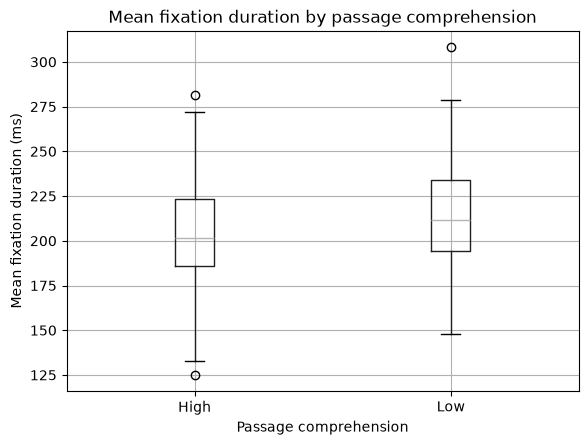

In [28]:
import matplotlib.pyplot as plt

analysis_complete.boxplot(
    column="mean_fix_duration",
    by="comprehension_level"
)

plt.xlabel("Passage comprehension")
plt.ylabel("Mean fixation duration (ms)")
plt.title("Mean fixation duration by passage comprehension")
plt.suptitle("")
plt.show()

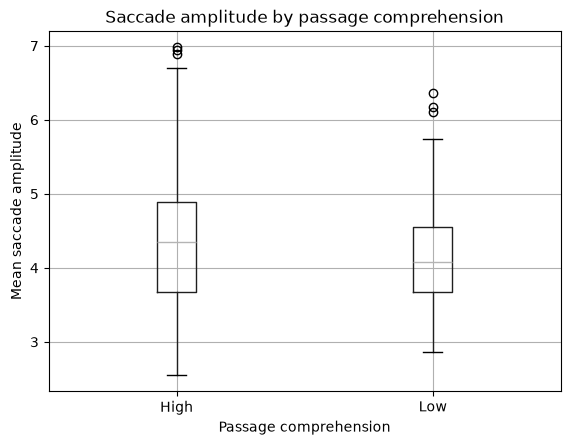

In [29]:
analysis_complete.boxplot(
    column="mean_saccade_amplitude",
    by="comprehension_level"
)

plt.xlabel("Passage comprehension")
plt.ylabel("Mean saccade amplitude")
plt.title("Saccade amplitude by passage comprehension")
plt.suptitle("")
plt.show()

## Initial descriptive results

The descriptive results show the same broad pattern as the original SB-SAT study:

* Low passage comprehension was associated with longer mean fixation durations
  (213.83 ms) than high comprehension (204.35 ms).
* Low passage comprehension showed smaller mean saccade amplitudes
  (4.16) than high comprehension (4.38).
* Participants also made more fixations on passages with low comprehension
  (721.67) than on passages with high comprehension (678.58).

However, the distributions show substantial overlap between the low- and
high-comprehension groups. These descriptive results therefore do not establish
whether the differences are statistically meaningful or whether they remain after
accounting for repeated observations from the same participants and differences
between passages.

In [30]:
predictors = [
    "mean_fix_duration",
    "median_fix_duration",
    "n_fixations",
    "mean_saccade_amplitude",
    "mean_pupil_size"
]

correlations = analysis_complete[predictors].corr()

print(correlations.round(2))

                        mean_fix_duration  median_fix_duration  n_fixations  \
mean_fix_duration                    1.00                 0.95         0.16   
median_fix_duration                  0.95                 1.00         0.13   
n_fixations                          0.16                 0.13         1.00   
mean_saccade_amplitude              -0.28                -0.23        -0.53   
mean_pupil_size                     -0.15                -0.20         0.01   

                        mean_saccade_amplitude  mean_pupil_size  
mean_fix_duration                        -0.28            -0.15  
median_fix_duration                      -0.23            -0.20  
n_fixations                              -0.53             0.01  
mean_saccade_amplitude                    1.00             0.17  
mean_pupil_size                           0.17             1.00  


### Why mixed-effects models?

Observations are not independent because each participant reads multiple
passages. Mixed-effects models are commonly used for repeated-measures data
in psycholinguistics and eye-tracking research because they can account for
variation between participants and items/texts.

In the current analysis:
* Participant is included as a random intercept.
* Passage is included as a fixed effect because there are only four passages.
* Eye-tracking measures are included as fixed-effect predictors.

The initial analyses use linear mixed-effects models for exploratory purposes.
However, passage comprehension is based on the number of correct answers out
of five questions (0–5), rather than a truly continuous outcome. Therefore, a
binomial generalized linear mixed-effects model (GLMM) would be preferable for
a final confirmatory analysis.

In [31]:
# Is mean fixation duration associated with passage comprehension, while accounting for repeated observations from the same participant and differences between passages?

# Standardizatoin: 0     = average fixation duration
# +1    = 1 SD longer than average
# -1    = 1 SD shorter than average

# C(book_name): systematic differences per passage
# groups=participant: participants have four observations, thus not independent

analysis_complete["z_fix_duration"] = (
    analysis_complete["mean_fix_duration"]
    - analysis_complete["mean_fix_duration"].mean()
) / analysis_complete["mean_fix_duration"].std()

import statsmodels.formula.api as smf

model_fix = smf.mixedlm(
    "comprehension_score ~ z_fix_duration + C(book_name)",
    data=analysis_complete,
    groups=analysis_complete["RECORDING_SESSION_LABEL"]
)

result_fix = model_fix.fit(reml=False)

print(result_fix.summary())

               Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  comprehension_score
No. Observations:  357      Method:              ML                 
No. Groups:        95       Scale:               0.0452             
Min. group size:   1        Log-Likelihood:      20.5411            
Max. group size:   4        Converged:           Yes                
Mean group size:   3.8                                              
--------------------------------------------------------------------
                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------
Intercept                  0.580    0.025 23.439 0.000  0.532  0.629
C(book_name)[T.flytrap]   -0.028    0.032 -0.879 0.380 -0.091  0.035
C(book_name)[T.genome]    -0.070    0.032 -2.163 0.031 -0.134 -0.007
C(book_name)[T.northpole]  0.041    0.032  1.270 0.204 -0.022  0.104
z_fix_duration            -0.035    0.015 -2.390 0

C:\Users\Tim\AppData\Local\Temp\ipykernel_1972\1333485859.py:23: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  result_fix = model_fix.fit(reml=False)


### Mixed-effects model: fixation duration

A linear mixed-effects model was used to examine whether mean fixation
duration was associated with passage comprehension. Participant was included
as a random intercept to account for repeated observations, and passage was
included as a fixed effect.

Mean fixation duration was standardized before analysis.

Longer mean fixation duration was significantly associated with lower
passage comprehension (β = -0.035, SE = 0.015, p = .017,
95% CI [-0.063, -0.006]).

Thus, a one-standard-deviation increase in mean fixation duration was
associated with an approximately 0.035 decrease in comprehension score,
after accounting for passage differences and repeated observations within
participants.

The model produced a boundary warning for the random-effect variance,
which should be considered when interpreting the model.

In [32]:
# Is greater mean saccade amplitude associated with passage comprehension, while accounting for repeated observations within participants and differences between passages?

# Standardize mean saccade amplitude
analysis_complete["z_saccade_amplitude"] = (
    analysis_complete["mean_saccade_amplitude"]
    - analysis_complete["mean_saccade_amplitude"].mean()
) / analysis_complete["mean_saccade_amplitude"].std()

# Mixed-effects model
model_saccade = smf.mixedlm(
    "comprehension_score ~ z_saccade_amplitude + C(book_name)",
    data=analysis_complete,
    groups=analysis_complete["RECORDING_SESSION_LABEL"]
)

result_saccade = model_saccade.fit(reml=False)

print(result_saccade.summary())

C:\Users\Tim\AppData\Local\Temp\ipykernel_1972\1504307507.py:16: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  result_saccade = model_saccade.fit(reml=False)


               Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  comprehension_score
No. Observations:  357      Method:              ML                 
No. Groups:        95       Scale:               0.0454             
Min. group size:   1        Log-Likelihood:      19.0192            
Max. group size:   4        Converged:           Yes                
Mean group size:   3.8                                              
--------------------------------------------------------------------
                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------
Intercept                  0.586    0.025 23.718 0.000  0.538  0.634
C(book_name)[T.flytrap]   -0.037    0.032 -1.168 0.243 -0.100  0.025
C(book_name)[T.genome]    -0.079    0.032 -2.444 0.015 -0.142 -0.016
C(book_name)[T.northpole]  0.035    0.032  1.086 0.278 -0.028  0.098
z_saccade_amplitude        0.024    0.015  1.597 0

### Mixed-effects model: saccade amplitude

A linear mixed-effects model was used to examine whether mean saccade
amplitude was associated with passage comprehension. Participant was included
as a random intercept to account for repeated observations, and passage was
included as a fixed effect.

Mean saccade amplitude was standardized before analysis.

Mean saccade amplitude showed a positive, but non-significant, association
with passage comprehension (β = 0.024, SE = 0.015, p = .110,
95% CI [-0.005, 0.053]).

Thus, larger saccade amplitudes tended to be associated with higher
comprehension, but there was insufficient statistical evidence for this
relationship after accounting for passage differences and repeated
observations within participants.

The direction of the association is consistent with the descriptive results
and with the original SB-SAT study, but the effect was not statistically
significant in the mixed-effects analysis.

In [33]:
# Are more fixations during a passage associated with lower passage comprehension, after accounting for passage differences and repeated observations within participants?

# Standardize fixation count
analysis_complete["z_fixation_count"] = (
    analysis_complete["n_fixations"]
    - analysis_complete["n_fixations"].mean()
) / analysis_complete["n_fixations"].std()

# Mixed-effects model
model_fix_count = smf.mixedlm(
    "comprehension_score ~ z_fixation_count + C(book_name)",
    data=analysis_complete,
    groups=analysis_complete["RECORDING_SESSION_LABEL"]
)

result_fix_count = model_fix_count.fit(reml=False)

print(result_fix_count.summary())

               Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  comprehension_score
No. Observations:  357      Method:              ML                 
No. Groups:        95       Scale:               0.0451             
Min. group size:   1        Log-Likelihood:      17.8678            
Max. group size:   4        Converged:           Yes                
Mean group size:   3.8                                              
--------------------------------------------------------------------
                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------
Intercept                  0.586    0.025 23.098 0.000  0.536  0.635
C(book_name)[T.flytrap]   -0.032    0.034 -0.926 0.354 -0.098  0.035
C(book_name)[T.genome]    -0.078    0.033 -2.349 0.019 -0.143 -0.013
C(book_name)[T.northpole]  0.029    0.032  0.907 0.364 -0.033  0.091
z_fixation_count          -0.006    0.015 -0.407 0

### Mixed-effects model: fixation count

A linear mixed-effects model was used to examine whether fixation count was
associated with passage comprehension. Participant was included as a random
intercept, and passage was included as a fixed effect.

Fixation count was standardized before analysis.

Fixation count was not significantly associated with passage comprehension
(β = -0.006, SE = 0.015, p = .684, 95% CI [-0.034, 0.023]).

Thus, the number of fixations made while reading a passage did not show a
meaningful relationship with passage comprehension after accounting for passage
differences and repeated observations within participants.

In [34]:
# Is mean pupil size associated with passage comprehension, after accounting for passage differences and repeated observations within participants?

# Standardize pupil size
analysis_complete["z_pupil_size"] = (
    analysis_complete["mean_pupil_size"]
    - analysis_complete["mean_pupil_size"].mean()
) / analysis_complete["mean_pupil_size"].std()

# Mixed-effects model
model_pupil = smf.mixedlm(
    "comprehension_score ~ z_pupil_size + C(book_name)",
    data=analysis_complete,
    groups=analysis_complete["RECORDING_SESSION_LABEL"]
)

result_pupil = model_pupil.fit(reml=False)

print(result_pupil.summary())

               Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  comprehension_score
No. Observations:  357      Method:              ML                 
No. Groups:        95       Scale:               0.0450             
Min. group size:   1        Log-Likelihood:      17.7854            
Max. group size:   4        Converged:           Yes                
Mean group size:   3.8                                              
--------------------------------------------------------------------
                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------
Intercept                  0.588    0.025 23.626 0.000  0.539  0.636
C(book_name)[T.flytrap]   -0.036    0.032 -1.132 0.258 -0.099  0.026
C(book_name)[T.genome]    -0.081    0.032 -2.518 0.012 -0.144 -0.018
C(book_name)[T.northpole]  0.028    0.032  0.887 0.375 -0.034  0.090
z_pupil_size               0.000    0.015  0.018 0

### Mixed-effects model: pupil size

A linear mixed-effects model was used to examine whether mean pupil size was
associated with passage comprehension. Participant was included as a random
intercept, and passage was included as a fixed effect.

Mean pupil size was standardized before analysis.

Mean pupil size was not associated with passage comprehension
(β = 0.000, SE = 0.015, p = .986, 95% CI [-0.030, 0.030]).

Thus, mean pupil size did not provide evidence of a relationship with passage
comprehension after accounting for passage differences and repeated observations
within participants.

This is consistent with the original SB-SAT study, which also did not find
significant differences in pupil size between comprehension groups.

In [35]:
# Is regression rate associated with passage comprehension,
# after accounting for passage differences and repeated observations within participants?

# Keep fixations that landed on a defined word/interest area
reading_words = reading.dropna(
    subset=["CURRENT_FIX_INTEREST_AREA_ID"]
).copy()

# Previous word/interest area within the same participant, passage, and page
reading_words["previous_ia_id"] = (
    reading_words
    .groupby([
        "RECORDING_SESSION_LABEL",
        "book_name",
        "page"
    ])["CURRENT_FIX_INTEREST_AREA_ID"]
    .shift(1)
)

# A regression occurs when gaze moves back to an earlier interest area
reading_words["is_regression"] = (
    reading_words["CURRENT_FIX_INTEREST_AREA_ID"]
    < reading_words["previous_ia_id"]
)

# Calculate regression features per participant × passage
regression_features = (
    reading_words
    .dropna(subset=["previous_ia_id"])
    .groupby(["RECORDING_SESSION_LABEL", "book_name"])
    .agg(
        n_regressions=("is_regression", "sum"),
        n_transitions=("is_regression", "count")
    )
    .reset_index()
)

# Proportion of word-to-word transitions that are regressions
regression_features["regression_rate"] = (
    regression_features["n_regressions"]
    / regression_features["n_transitions"]
)

print(regression_features.head())

  RECORDING_SESSION_LABEL  book_name  n_regressions  n_transitions  \
0                  msd001    dickens             94            491   
1                  msd001    flytrap            139            632   
2                  msd001     genome             72            488   
3                  msd001  northpole             65            366   
4                  msd002    dickens             98            632   

   regression_rate  
0         0.191446  
1         0.219937  
2         0.147541  
3         0.177596  
4         0.155063  


In [36]:
analysis_complete = analysis_complete.merge(
    regression_features,
    on=["RECORDING_SESSION_LABEL", "book_name"],
    how="left"
)

print(
    analysis_complete[
        ["n_regressions", "n_transitions", "regression_rate"]
    ].describe()
)

       n_regressions  n_transitions  regression_rate
count     357.000000     357.000000       357.000000
mean      137.081232     657.563025         0.208501
std        55.037134     182.291946         0.056074
min        14.000000      49.000000         0.039720
25%        97.000000     527.000000         0.173112
50%       130.000000     645.000000         0.206349
75%       167.000000     789.000000         0.244074
max       390.000000    1139.000000         0.403712


In [37]:
# Standardize regression rate
analysis_complete["z_regression_rate"] = (
    analysis_complete["regression_rate"]
    - analysis_complete["regression_rate"].mean()
) / analysis_complete["regression_rate"].std()

# Mixed-effects model
model_regression = smf.mixedlm(
    "comprehension_score ~ z_regression_rate + C(book_name)",
    data=analysis_complete,
    groups=analysis_complete["RECORDING_SESSION_LABEL"]
)

result_regression = model_regression.fit(reml=False)

print(result_regression.summary())

               Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  comprehension_score
No. Observations:  357      Method:              ML                 
No. Groups:        95       Scale:               0.0449             
Min. group size:   1        Log-Likelihood:      18.4451            
Max. group size:   4        Converged:           Yes                
Mean group size:   3.8                                              
--------------------------------------------------------------------
                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------
Intercept                  0.584    0.025 23.407 0.000  0.535  0.633
C(book_name)[T.flytrap]   -0.032    0.032 -0.987 0.323 -0.095  0.031
C(book_name)[T.genome]    -0.076    0.032 -2.346 0.019 -0.139 -0.012
C(book_name)[T.northpole]  0.032    0.032  1.007 0.314 -0.030  0.094
z_regression_rate          0.017    0.015  1.150 0

### Mixed-effects model: regression rate

A linear mixed-effects model was used to examine whether regression rate was
associated with passage comprehension. Participant was included as a random
intercept, and passage was included as a fixed effect.

Regression rate was standardized before analysis.

Regression rate was not significantly associated with passage comprehension
(β = 0.017, SE = 0.015, p = .250, 95% CI [-0.012, 0.046]).

The coefficient was positive, suggesting that a higher regression rate tended
to be associated with slightly higher comprehension, but there was insufficient
statistical evidence for this relationship after accounting for passage
differences and repeated observations within participants.

### Follow-up analysis: binomial generalized linear mixed-effects model

The initial analyses used linear mixed-effects models with passage comprehension
score (0.0–1.0) as the outcome.

However, passage comprehension is based on the number of correct answers to
five comprehension questions. The possible scores are therefore discrete
(0, 0.2, 0.4, 0.6, 0.8, and 1.0), rather than truly continuous.

A binomial generalized linear mixed-effects model (GLMM) is therefore more
appropriate for a confirmatory analysis because it models whether individual
comprehension questions were answered correctly or incorrectly.

The first GLMM focuses on mean fixation duration because this was the only
eye-tracking measure that showed a statistically significant association with
comprehension in the exploratory linear mixed-effects models.

The model examines whether mean fixation duration predicts the probability of
answering a comprehension question correctly while:
* accounting for repeated observations from the same participant using a
  participant random intercept;
* controlling for systematic differences between passages using passage as a
  fixed effect.

The aim is to examine whether the negative relationship between fixation
duration and comprehension remains when the outcome is modelled using a
binomial distribution.

In [38]:
# Keep fixation duration for the complete participant × passage observations
fixation_for_glmm = analysis_complete[
    [
        "RECORDING_SESSION_LABEL",
        "book_name",
        "z_fix_duration"
    ]
].copy()

# Merge passage-level fixation duration with individual comprehension questions
glmm_df = comprehension_questions.merge(
    fixation_for_glmm,
    on=["RECORDING_SESSION_LABEL", "book_name"],
    how="inner"
)

print(glmm_df.head(10))
print(glmm_df.shape)
print(glmm_df["correct"].value_counts())

  RECORDING_SESSION_LABEL book_name  page  answer  correct_answer  correct  \
0                  msd001   dickens     1       1               1        1   
1                  msd001   dickens     2       3               3        1   
2                  msd001   dickens     3       3               1        0   
3                  msd001   dickens     4       4               4        1   
4                  msd001   dickens     5       2               3        0   
5                  msd001   flytrap     1       1               1        1   
6                  msd001   flytrap     2       3               3        1   
7                  msd001   flytrap     3       4               4        1   
8                  msd001   flytrap     4       2               2        1   
9                  msd001   flytrap     5       4               2        0   

   z_fix_duration  
0       -0.874583  
1       -0.874583  
2       -0.874583  
3       -0.874583  
4       -0.874583  
5       -0.311707  
6

In [39]:
from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM

# Is mean fixation duration associated with the probability of answering
# a comprehension question correctly?

model_glmm_fix = BinomialBayesMixedGLM.from_formula(
    "correct ~ z_fix_duration + C(book_name)",
    {
        "participant": "0 + C(RECORDING_SESSION_LABEL)"
    },
    glmm_df
)

result_glmm_fix = model_glmm_fix.fit_vb()

print(result_glmm_fix.summary())

                       Binomial Mixed GLM Results
                          Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
------------------------------------------------------------------------
Intercept                    M     0.3395   0.0487                      
C(book_name)[T.flytrap]      M    -0.1189   0.0969                      
C(book_name)[T.genome]       M    -0.2952   0.0975                      
C(book_name)[T.northpole]    M     0.1772   0.0973                      
z_fix_duration               M    -0.1479   0.0490                      
participant                  V    -0.9177   0.0727 0.399   0.345   0.462
Parameter types are mean structure (M) and variance structure (V)
Variance parameters are modeled as log standard deviations


### Binomial GLMM: fixation duration

Because passage comprehension is based on five individual comprehension
questions, a binomial mixed-effects model was used as a follow-up analysis.

Correct/incorrect responses to individual comprehension questions were used
as the outcome. Mean fixation duration was measured at the participant × passage
level and standardized before analysis.

Participant was included as a random intercept to account for repeated
observations, and passage was included as a fixed effect.

Mean fixation duration showed a negative association with the probability of
answering a comprehension question correctly
(posterior mean = -0.148, posterior SD = 0.049).

Thus, longer mean fixation durations were associated with a lower probability
of answering comprehension questions correctly.

This result is consistent with the earlier linear mixed-effects model:

* **LMM:** longer fixation duration was associated with lower passage
  comprehension (β = -0.035, p = .017).
* **Binomial GLMM:** longer fixation duration was associated with a lower
  probability of answering an individual comprehension question correctly
  (posterior mean = -0.148, posterior SD = 0.049).

The consistency between the two analyses strengthens the evidence that mean
fixation duration is related to comprehension.

#### Participant differences

The estimated standard deviation of the participant random intercept was
approximately 0.399. This indicates variation between participants in their
general probability of answering comprehension questions correctly, supporting
the inclusion of participant as a random effect.

#### Passage differences

Dickens was the reference passage. Relative to Dickens, the estimated passage
effects were:

* Flytrap: -0.119
* Genome: -0.295
* Northpole: 0.177

Genome showed the strongest negative estimated difference relative to Dickens.
These passage effects are included primarily to control for systematic
differences between texts rather than being the main focus of the analysis.

### Next analysis: multivariable GLMM

The previous analyses examined each eye-tracking measure separately.

The next step is to examine whether mean fixation duration remains associated
with comprehension when other characteristics of reading behaviour are included
in the same model.

A multivariable binomial GLMM will include:

* mean fixation duration;
* mean saccade amplitude;
* regression rate;
* passage as a fixed effect;
* participant as a random intercept.

This allows examination of the independent association of each eye-tracking
measure with the probability of answering a comprehension question correctly.

Mean and median fixation duration will not both be included because they are
very highly correlated (r = .95). Pupil size and fixation count are initially
excluded because the previous single-predictor analyses showed little evidence
of an association with comprehension.

In [40]:
# Standardize additional predictors at participant × passage level
analysis_complete["z_saccade_amplitude"] = (
    analysis_complete["mean_saccade_amplitude"]
    - analysis_complete["mean_saccade_amplitude"].mean()
) / analysis_complete["mean_saccade_amplitude"].std()

analysis_complete["z_regression_rate"] = (
    analysis_complete["regression_rate"]
    - analysis_complete["regression_rate"].mean()
) / analysis_complete["regression_rate"].std()

In [41]:
predictors_for_glmm = analysis_complete[
    [
        "RECORDING_SESSION_LABEL",
        "book_name",
        "z_fix_duration",
        "z_saccade_amplitude",
        "z_regression_rate"
    ]
].copy()

glmm_multi_df = comprehension_questions.merge(
    predictors_for_glmm,
    on=["RECORDING_SESSION_LABEL", "book_name"],
    how="inner"
)

print(glmm_multi_df.head())
print(glmm_multi_df.shape)

  RECORDING_SESSION_LABEL book_name  page  answer  correct_answer  correct  \
0                  msd001   dickens     1       1               1        1   
1                  msd001   dickens     2       3               3        1   
2                  msd001   dickens     3       3               1        0   
3                  msd001   dickens     4       4               4        1   
4                  msd001   dickens     5       2               3        0   

   z_fix_duration  z_saccade_amplitude  z_regression_rate  
0       -0.874583             1.278931           -0.30416  
1       -0.874583             1.278931           -0.30416  
2       -0.874583             1.278931           -0.30416  
3       -0.874583             1.278931           -0.30416  
4       -0.874583             1.278931           -0.30416  
(1785, 9)


from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM

model_glmm_multi = BinomialBayesMixedGLM.from_formula(
    """
    correct ~
        z_fix_duration +
        z_saccade_amplitude +
        z_regression_rate +
        C(book_name)
    """,
    {
        "participant": "0 + C(RECORDING_SESSION_LABEL)"
    },
    glmm_multi_df
)

result_glmm_multi = model_glmm_multi.fit_vb()

print(result_glmm_multi.summary())

### Multivariable binomial GLMM

A multivariable binomial mixed-effects model was used to examine whether
mean fixation duration remained associated with comprehension when other
eye-tracking characteristics were considered simultaneously.

The model included:
* mean fixation duration;
* mean saccade amplitude;
* regression rate;
* passage as a fixed effect;
* participant as a random intercept.

All eye-tracking predictors were standardized before analysis.

Mean fixation duration remained negatively associated with the probability
of answering a comprehension question correctly
(posterior mean = -0.127, posterior SD = 0.049).

The approximate 95% posterior interval for fixation duration was
[-0.223, -0.031], remaining below zero.

On the odds scale, this corresponds to an odds ratio of approximately 0.88.
Thus, a one-standard-deviation increase in mean fixation duration was
associated with approximately 12% lower odds of answering a comprehension
question correctly, while holding the other predictors and passage constant.

Mean saccade amplitude showed a positive estimate
(posterior mean = 0.061, posterior SD = 0.050), but its approximate 95%
posterior interval included zero.

Regression rate also showed little evidence of an independent association
with comprehension
(posterior mean = 0.026, posterior SD = 0.049).

Overall, mean fixation duration was the only included eye-tracking measure
that showed a clear independent relationship with comprehension in this model.

Is comprehension related to the fact that some students generally have longer fixations than others, or is it related to a student having longer fixations than usual for that particular student on a passage?

In [42]:
# Participant's average fixation duration across passages
analysis_complete["person_mean_fix_duration"] = (
    analysis_complete
    .groupby("RECORDING_SESSION_LABEL")["mean_fix_duration"]
    .transform("mean")
)

# Deviation from that participant's own average
analysis_complete["within_fix_duration"] = (
    analysis_complete["mean_fix_duration"]
    - analysis_complete["person_mean_fix_duration"]
)

In [43]:
analysis_complete["z_between_fix_duration"] = (
    analysis_complete["person_mean_fix_duration"]
    - analysis_complete["person_mean_fix_duration"].mean()
) / analysis_complete["person_mean_fix_duration"].std()

analysis_complete["z_within_fix_duration"] = (
    analysis_complete["within_fix_duration"]
    - analysis_complete["within_fix_duration"].mean()
) / analysis_complete["within_fix_duration"].std()

In [44]:
within_between_predictors = analysis_complete[
    [
        "RECORDING_SESSION_LABEL",
        "book_name",
        "z_between_fix_duration",
        "z_within_fix_duration"
    ]
].copy()

glmm_within_between = comprehension_questions.merge(
    within_between_predictors,
    on=["RECORDING_SESSION_LABEL", "book_name"],
    how="inner"
)

In [45]:
model_within_between = BinomialBayesMixedGLM.from_formula(
    """
    correct ~
        z_between_fix_duration +
        z_within_fix_duration +
        C(book_name)
    """,
    {
        "participant": "0 + C(RECORDING_SESSION_LABEL)"
    },
    glmm_within_between
)

result_within_between = model_within_between.fit_vb()

print(result_within_between.summary())

                       Binomial Mixed GLM Results
                          Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
------------------------------------------------------------------------
Intercept                    M     0.3759   0.0488                      
C(book_name)[T.flytrap]      M    -0.1537   0.0970                      
C(book_name)[T.genome]       M    -0.3457   0.0975                      
C(book_name)[T.northpole]    M     0.1197   0.0974                      
z_between_fix_duration       M    -0.1619   0.0489                      
z_within_fix_duration        M     0.0043   0.0493                      
participant                  V    -0.9185   0.0727 0.399   0.345   0.462
Parameter types are mean structure (M) and variance structure (V)
Variance parameters are modeled as log standard deviations


### Within-person versus between-person fixation duration

To examine whether the fixation-duration effect reflects differences between
students or changes within the same student across passages, mean fixation
duration was decomposed into:

* **Between-person fixation duration:** a participant's average fixation
  duration across passages.
* **Within-person fixation duration:** the deviation in fixation duration for
  a particular passage from that participant's own average.

A binomial mixed-effects model included both components, passage as a fixed
effect, and participant as a random intercept.

The between-person fixation-duration effect was clearly negative
(posterior mean = -0.162, posterior SD = 0.049; approximate 95% posterior
interval [-0.258, -0.066]).

This corresponds to an odds ratio of approximately 0.85: participants whose
average fixation duration was one standard deviation higher had approximately
15% lower odds of answering a comprehension question correctly.

In contrast, the within-person fixation-duration effect was close to zero
(posterior mean = 0.004, posterior SD = 0.049; approximate 95% posterior
interval [-0.092, 0.101]).

Thus, the previously observed relationship between longer fixation durations
and lower comprehension appears to be primarily a **between-reader effect**.
There was no clear evidence that a student having longer fixations than usual
on a particular passage was associated with lower comprehension on that
passage.

This distinction is relevant for interpreting eye-tracking analytics:
fixation duration may reflect relatively stable differences between readers
more strongly than passage-specific comprehension difficulty.

In [46]:
# Sensitivity analysis:
# Remove the unusually sparse msd012 × dickens recording

analysis_sensitivity = analysis_complete[
    ~(
        (analysis_complete["RECORDING_SESSION_LABEL"] == "msd012") &
        (analysis_complete["book_name"] == "dickens")
    )
].copy()

print(analysis_complete.shape)
print(analysis_sensitivity.shape)

(357, 26)
(356, 26)


In [47]:
predictors_sensitivity = analysis_sensitivity[
    [
        "RECORDING_SESSION_LABEL",
        "book_name",
        "z_fix_duration",
        "z_saccade_amplitude",
        "z_regression_rate"
    ]
].copy()

glmm_sensitivity_df = comprehension_questions.merge(
    predictors_sensitivity,
    on=["RECORDING_SESSION_LABEL", "book_name"],
    how="inner"
)

print(glmm_sensitivity_df.shape)

(1780, 9)


In [48]:
model_glmm_sensitivity = BinomialBayesMixedGLM.from_formula(
    """
    correct ~
        z_fix_duration +
        z_saccade_amplitude +
        z_regression_rate +
        C(book_name)
    """,
    {
        "participant": "0 + C(RECORDING_SESSION_LABEL)"
    },
    glmm_sensitivity_df
)

result_glmm_sensitivity = model_glmm_sensitivity.fit_vb()

print(result_glmm_sensitivity.summary())

                       Binomial Mixed GLM Results
                          Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
------------------------------------------------------------------------
Intercept                    M     0.3414   0.0488                      
C(book_name)[T.flytrap]      M    -0.1268   0.0970                      
C(book_name)[T.genome]       M    -0.2945   0.0976                      
C(book_name)[T.northpole]    M     0.1884   0.0974                      
z_fix_duration               M    -0.1309   0.0493                      
z_saccade_amplitude          M     0.0631   0.0498                      
z_regression_rate            M     0.0269   0.0491                      
participant                  V    -0.9333   0.0727 0.393   0.340   0.455
Parameter types are mean structure (M) and variance structure (V)
Variance parameters are modeled as log standard deviations


### Sensitivity analysis

One participant–passage observation (`msd012 × Dickens`) contained all five
pages but only 56 recorded fixations, making it an unusually sparse eye-tracking
recording.

To examine whether this observation influenced the main findings, the
multivariable binomial GLMM was repeated after excluding this observation.

The results were virtually unchanged:

* Mean fixation duration:
  * Original model: posterior mean = -0.127
  * Sensitivity model: posterior mean = -0.131, posterior SD = 0.049
* Mean saccade amplitude:
  * Original model: 0.061
  * Sensitivity model: 0.063
* Regression rate:
  * Original model: 0.026
  * Sensitivity model: 0.027

The approximate 95% posterior interval for mean fixation duration remained
below zero [-0.228, -0.034].

Thus, the negative relationship between mean fixation duration and
comprehension was not driven by the unusually sparse recording and appears
robust to its exclusion.

# Machine-learning analysis

## Aim

The aim of the machine-learning analysis is to examine whether eye-tracking
behaviour can be used to predict passage comprehension.

The statistical analyses above examined associations between individual
eye-tracking measures and comprehension. The machine-learning analysis extends
this by examining whether multiple eye-tracking features can jointly distinguish
between low and high passage comprehension.

## Prediction target

The initial prediction target is:

* **Passage comprehension: Low vs High**

This follows the definition used in the original SB-SAT study:
* High comprehension: comprehension score >= median (.60)
* Low comprehension: comprehension score < median (.60)

The unit of analysis remains **participant × passage**, so the eye-tracking
features used to make a prediction correspond to the same passage for which
comprehension was measured.

## Initial features

The first analysis will use interpretable, passage-level eye-tracking features:

* Mean fixation duration
* Mean saccade amplitude
* Fixation count
* Regression rate
* Mean pupil size

These features provide a simple baseline and allow the model predictions to
remain relatively interpretable.

The statistical analysis already suggests that mean fixation duration may be
particularly informative, but all selected measures will initially be included
so that the machine-learning models can examine their joint predictive value.

## Models

Three common supervised machine-learning approaches will initially be compared:

1. **Logistic regression**
   * Provides an interpretable baseline.
   * Allows examination of the direction and relative contribution of features.

2. **Random Forest**
   * Can capture nonlinear relationships and interactions between eye-tracking
     measures.
   * Provides feature-importance estimates.

3. **Support Vector Machine (SVM)**
   * Suitable for relatively small tabular datasets.
   * Can model more complex decision boundaries than logistic regression.

## Model evaluation

Evaluation should be performed at the **participant level**, rather than by
randomly splitting participant–passage observations.

The same participant should not occur in both the training and test sets.

This is important because eye-tracking behaviour contains substantial individual
differences. A random row-level split could allow the model to learn
participant-specific reading characteristics and therefore overestimate how well
the model generalizes to unseen students.

Participant-grouped cross-validation (e.g., GroupKFold) will therefore be used.

Because the Low and High comprehension classes are not perfectly balanced,
model performance should not be evaluated using accuracy alone.

Possible evaluation metrics include:

* Balanced accuracy
* F1-score
* ROC-AUC
* Confusion matrix

Performance should also be compared with a simple majority-class baseline.

## Important limitation of the initial feature-based approach

The initial machine-learning analysis aggregates eye movements over the complete
passage. This improves interpretability and aligns the predictors with the
passage-level comprehension outcome, but it removes the temporal structure of
the eye-tracking data.

For example, two students could have the same mean fixation duration while
showing very different reading behaviour over time.

Therefore, a subsequent analysis can investigate the **time-series structure**
of the eye-tracking data rather than relying only on summary statistics.

Possible later approaches include:

* fixation sequences;
* temporal changes in fixation duration;
* sequences of saccade behaviour;
* Dynamic Time Warping (DTW);
* time-series classification;
* sequence models such as 1D-CNNs or recurrent neural networks.

This provides two complementary perspectives:

**Feature-based ML**
→ interpretable summary of reading behaviour across a passage

**Time-series ML**
→ preserves how reading behaviour develops throughout the passage

# Feature based

## data preperation

In [49]:
# Features for the initial feature-based ML analysis
ml_features = [
    "mean_fix_duration",
    "mean_saccade_amplitude",
    "n_fixations",
    "regression_rate",
    "mean_pupil_size"
]

# Create ML dataframe
ml_df = analysis_complete[
    [
        "RECORDING_SESSION_LABEL",
        "book_name",
        "comprehension_level"
    ] + ml_features
].dropna().copy()

# Encode target:
# Low = 0
# High = 1
ml_df["target"] = (
    ml_df["comprehension_level"] == "High"
).astype(int)

# Predictors, target, and participant groups
X = ml_df[ml_features]
y = ml_df["target"]
groups = ml_df["RECORDING_SESSION_LABEL"]

print("Number of observations:", len(ml_df))
print("Number of participants:", ml_df["RECORDING_SESSION_LABEL"].nunique())

print("\nClass distribution:")
print(ml_df["comprehension_level"].value_counts())

print("\nClass proportions:")
print(ml_df["comprehension_level"].value_counts(normalize=True).round(3))

print("\nFeatures:")
print(X.head())

Number of observations: 357
Number of participants: 95

Class distribution:
comprehension_level
High    219
Low     138
Name: count, dtype: int64

Class proportions:
comprehension_level
High    0.613
Low     0.387
Name: proportion, dtype: float64

Features:
   mean_fix_duration  mean_saccade_amplitude  n_fixations  regression_rate  \
0         182.131373                5.353921          510         0.191446   
1         198.790373                4.832022          644         0.219937   
2         205.161677                4.912505          501         0.147541   
3         184.591146                4.548945          384         0.177596   
4         234.771053                3.406000          760         0.155063   

   mean_pupil_size  
0      1610.600000  
1      1684.288820  
2      1609.059880  
3      1456.223958  
4      1727.018421  


In [50]:
from sklearn.model_selection import StratifiedGroupKFold

RANDOM_STATE = 88

# Group
#→ keeps all passages from one participant in the same fold --> original SB-SAT study found substantial problems generalizing to new readers

#Stratified
#→ tries to keep the Low/High class distribution reasonably similar across folds

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [51]:
train_idx, test_idx = next(
    cv.split(X, y, groups=groups)
)

train_participants = set(groups.iloc[train_idx])
test_participants = set(groups.iloc[test_idx])

print("Training observations:", len(train_idx))
print("Test observations:", len(test_idx))

print("Training participants:", len(train_participants))
print("Test participants:", len(test_participants))

print(
    "Participants appearing in both:",
    train_participants.intersection(test_participants)
)

Training observations: 287
Test observations: 70
Training participants: 77
Test participants: 18
Participants appearing in both: set()


## Baseline + logistic regression

In [52]:
import pandas as pd

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate


# Evaluation metrics
scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

In [53]:
# Majority-class baseline
baseline = DummyClassifier(strategy="most_frequent")

baseline_results = cross_validate(
    baseline,
    X,
    y,
    groups=groups,
    cv=cv,
    scoring=scoring
)

print("Baseline performance:")

for metric in scoring:
    scores = baseline_results[f"test_{metric}"]
    print(
        f"{metric}: {scores.mean():.3f} "
        f"(SD = {scores.std():.3f})"
    )

Baseline performance:
accuracy: 0.613 (SD = 0.009)
balanced_accuracy: 0.500 (SD = 0.000)
f1: 0.760 (SD = 0.007)
roc_auc: 0.500 (SD = 0.000)


In [54]:
# Logistic regression pipeline
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

logistic_results = cross_validate(
    logistic_model,
    X,
    y,
    groups=groups,
    cv=cv,
    scoring=scoring
)

print("\nLogistic regression performance:")

for metric in scoring:
    scores = logistic_results[f"test_{metric}"]
    print(
        f"{metric}: {scores.mean():.3f} "
        f"(SD = {scores.std():.3f})"
    )


Logistic regression performance:
accuracy: 0.599 (SD = 0.043)
balanced_accuracy: 0.518 (SD = 0.042)
f1: 0.728 (SD = 0.031)
roc_auc: 0.553 (SD = 0.040)


In [55]:
comparison = pd.DataFrame({
    "Metric": list(scoring.keys()),
    "Baseline": [
        baseline_results[f"test_{metric}"].mean()
        for metric in scoring
    ],
    "Logistic Regression": [
        logistic_results[f"test_{metric}"].mean()
        for metric in scoring
    ]
})

print(comparison.round(3))

              Metric  Baseline  Logistic Regression
0           accuracy     0.613                0.599
1  balanced_accuracy     0.500                0.518
2                 f1     0.760                0.728
3            roc_auc     0.500                0.553


### Logistic regression baseline

A logistic regression model was evaluated using 5-fold
StratifiedGroupKFold cross-validation, ensuring that participants in the
test folds were not present in the training data.

Performance was compared with a majority-class baseline.

| Metric | Baseline | Logistic regression |
|---|---:|---:|
| Accuracy | 0.613 | 0.599 |
| Balanced accuracy | 0.500 | 0.518 |
| F1-score | 0.760 | 0.728 |
| ROC-AUC | 0.500 | 0.553 |

Logistic regression showed only limited predictive performance.

Although balanced accuracy (0.518) and ROC-AUC (0.553) were slightly above
chance, overall accuracy was lower than the majority-class baseline.

This suggests that the selected aggregated eye-tracking features contain some
information related to comprehension, but are insufficient for reliably
classifying Low versus High passage comprehension for unseen participants.

This also illustrates the distinction between statistical association and
predictive performance: an eye-tracking measure may show a statistically
detectable relationship with comprehension without being sufficiently
informative for accurate individual predictions.

In [56]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=2000,
        solver="liblinear",
        random_state=RANDOM_STATE
    ))
])

param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__l1_ratio": [0.0, 1.0],
    "classifier__class_weight": [None, "balanced"]
}

grid_search = GridSearchCV(
    logistic_pipeline,
    param_grid=param_grid,
    scoring="balanced_accuracy",
    cv=cv,
    n_jobs=-1
)

grid_search.fit(
    X,
    y,
    groups=groups
)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validated balanced accuracy:")
print(grid_search.best_score_)

Best parameters:
{'classifier__C': 0.1, 'classifier__class_weight': 'balanced', 'classifier__l1_ratio': 1.0}

Best cross-validated balanced accuracy:
0.575340378235326


In [57]:
# Logistic regression using the best parameters from grid search

tuned_logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        C=0.1,
        class_weight="balanced",
        l1_ratio = 1.0,
        solver="liblinear",
        max_iter=2000,
        random_state=RANDOM_STATE
    ))
])

tuned_logistic_results = cross_validate(
    tuned_logistic_model,
    X,
    y,
    groups=groups,
    cv=cv,
    scoring=scoring
)

print("Tuned logistic regression performance:")

for metric in scoring:
    scores = tuned_logistic_results[f"test_{metric}"]

    print(f"\n{metric}:")
    print("Fold scores:", scores.round(3))
    print(
        f"Mean = {scores.mean():.3f}, "
        f"SD = {scores.std():.3f}"
    )

Tuned logistic regression performance:

accuracy:
Fold scores: [0.571 0.556 0.69  0.5   0.542]
Mean = 0.572, SD = 0.064

balanced_accuracy:
Fold scores: [0.617 0.561 0.636 0.519 0.544]
Mean = 0.575, SD = 0.044

f1:
Fold scores: [0.545 0.59  0.776 0.514 0.593]
Mean = 0.603, SD = 0.091

roc_auc:
Fold scores: [0.552 0.576 0.63  0.519 0.565]
Mean = 0.568, SD = 0.036


In [58]:
comparison_tuned = pd.DataFrame({
    "Metric": list(scoring.keys()),
    "Baseline": [
        baseline_results[f"test_{metric}"].mean()
        for metric in scoring
    ],
    "Original Logistic": [
        logistic_results[f"test_{metric}"].mean()
        for metric in scoring
    ],
    "Tuned Logistic": [
        tuned_logistic_results[f"test_{metric}"].mean()
        for metric in scoring
    ]
})

print(comparison_tuned.round(3))

              Metric  Baseline  Original Logistic  Tuned Logistic
0           accuracy     0.613              0.599           0.572
1  balanced_accuracy     0.500              0.518           0.575
2                 f1     0.760              0.728           0.603
3            roc_auc     0.500              0.553           0.568


### Tuned logistic regression

Hyperparameters were optimized using participant-grouped cross-validation,
with balanced accuracy as the optimization criterion.

The best parameters were:

* C = 0.1
* L1 regularization
* class_weight = balanced

Performance:

| Metric | Baseline | Original Logistic | Tuned Logistic |
|---|---:|---:|---:|
| Accuracy | 0.613 | 0.599 | 0.572 |
| Balanced accuracy | 0.500 | 0.518 | 0.575 |
| F1-score | 0.760 | 0.728 | 0.603 |
| ROC-AUC | 0.500 | 0.553 | 0.568 |

Tuning improved balanced accuracy from 0.518 to 0.575 and slightly improved
ROC-AUC from 0.553 to 0.568.

The decrease in overall accuracy and F1-score is partly explained by the use
of balanced class weights. Rather than favouring the majority High-comprehension
class, the tuned model gives greater importance to correctly identifying the
minority Low-comprehension class.

Overall, the tuned logistic regression performed better at distinguishing the
two comprehension groups, but predictive performance for unseen participants
remained modest.

### Random Forest

A Random Forest classifier was used to examine whether nonlinear relationships
and interactions between eye-tracking measures improve prediction of passage
comprehension.

The same five passage-level eye-tracking features were used:

* Mean fixation duration
* Mean saccade amplitude
* Fixation count
* Regression rate
* Mean pupil size

The model was evaluated using the same 5-fold StratifiedGroupKFold procedure,
ensuring that participants in the test fold were not present in the training data.

Unlike logistic regression, Random Forest does not assume a linear relationship
between the predictors and comprehension and can model interactions between
eye-tracking measures.

Because the comprehension classes are imbalanced, balanced class weights are
used initially.

In [59]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate

random_forest = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_results = cross_validate(
    random_forest,
    X,
    y,
    groups=groups,
    cv=cv,
    scoring=scoring
)

print("Random Forest performance:")

for metric in scoring:
    scores = rf_results[f"test_{metric}"]

    print(f"\n{metric}:")
    print("Fold scores:", scores.round(3))
    print(
        f"Mean = {scores.mean():.3f}, "
        f"SD = {scores.std():.3f}"
    )

Random Forest performance:

accuracy:
Fold scores: [0.457 0.625 0.606 0.569 0.625]
Mean = 0.576, SD = 0.063

balanced_accuracy:
Fold scores: [0.469 0.607 0.574 0.524 0.619]
Mean = 0.559, SD = 0.056

f1:
Fold scores: [0.486 0.69  0.689 0.674 0.682]
Mean = 0.644, SD = 0.079

roc_auc:
Fold scores: [0.479 0.668 0.641 0.557 0.644]
Mean = 0.598, SD = 0.070


In [60]:
comparison_rf = pd.DataFrame({
    "Metric": list(scoring.keys()),

    "Baseline": [
        baseline_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Tuned Logistic": [
        tuned_logistic_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Random Forest": [
        rf_results[f"test_{metric}"].mean()
        for metric in scoring
    ]
})

print(comparison_rf.round(3))

              Metric  Baseline  Tuned Logistic  Random Forest
0           accuracy     0.613           0.572          0.576
1  balanced_accuracy     0.500           0.575          0.559
2                 f1     0.760           0.603          0.644
3            roc_auc     0.500           0.568          0.598


### Random Forest results

A Random Forest classifier was evaluated using the same participant-grouped
5-fold cross-validation procedure as the logistic regression models.

Performance:

| Metric | Baseline | Tuned Logistic | Random Forest |
|---|---:|---:|---:|
| Accuracy | 0.613 | 0.572 | 0.576 |
| Balanced accuracy | 0.500 | 0.575 | 0.559 |
| F1-score | 0.760 | 0.603 | 0.644 |
| ROC-AUC | 0.500 | 0.568 | 0.598 |

The Random Forest achieved a similar balanced accuracy to the tuned logistic
regression, but a higher ROC-AUC (0.606 vs. 0.568).

This suggests that nonlinear relationships and interactions between the
eye-tracking features may contain some additional predictive information.

However, predictive performance remains modest, indicating that the aggregated
passage-level features alone are not sufficient for reliable classification of
comprehension in unseen participants.

In [61]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf_pipeline = RandomForestClassifier(
    n_estimators=500,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

param_grid_rf = {
    "max_depth": [None, 3, 5, 8, 12],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", None],
    "class_weight": [None, "balanced", "balanced_subsample"]
}

grid_search_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    scoring="balanced_accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(
    X,
    y,
    groups=groups
)

print("Best parameters:")
print(grid_search_rf.best_params_)

print("\nBest cross-validated balanced accuracy:")
print(grid_search_rf.best_score_)

Fitting 5 folds for each of 540 candidates, totalling 2700 fits
Best parameters:
{'class_weight': 'balanced_subsample', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10}

Best cross-validated balanced accuracy:
0.6136328207418824


In [62]:
# Create tuned Random Forest using the best parameters from GridSearchCV

tuned_rf = RandomForestClassifier(
    n_estimators=500,
    class_weight='balanced_subsample',
    max_depth=5,
    max_features='sqrt',
    min_samples_leaf=4,
    min_samples_split=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Evaluate tuned Random Forest using the same grouped cross-validation
tuned_rf_results = cross_validate(
    tuned_rf,
    X,
    y,
    groups=groups,
    cv=cv,
    scoring=scoring
)

print("Tuned Random Forest performance:")

for metric in scoring:
    scores = tuned_rf_results[f"test_{metric}"]

    print(f"\n{metric}:")
    print("Fold scores:", scores.round(3))
    print(
        f"Mean = {scores.mean():.3f}, "
        f"SD = {scores.std():.3f}"
    )

Tuned Random Forest performance:

accuracy:
Fold scores: [0.486 0.681 0.676 0.653 0.667]
Mean = 0.632, SD = 0.074

balanced_accuracy:
Fold scores: [0.512 0.66  0.631 0.606 0.659]
Mean = 0.614, SD = 0.054

f1:
Fold scores: [0.486 0.742 0.758 0.742 0.721]
Mean = 0.690, SD = 0.103

roc_auc:
Fold scores: [0.489 0.673 0.595 0.594 0.662]
Mean = 0.603, SD = 0.065


In [63]:
comparison_all = pd.DataFrame({
    "Metric": list(scoring.keys()),

    "Baseline": [
        baseline_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Tuned Logistic": [
        tuned_logistic_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Basic Random Forest": [
        rf_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Tuned Random Forest": [
        tuned_rf_results[f"test_{metric}"].mean()
        for metric in scoring
    ]
})

print(comparison_all.round(3))

              Metric  Baseline  Tuned Logistic  Basic Random Forest  \
0           accuracy     0.613           0.572                0.576   
1  balanced_accuracy     0.500           0.575                0.559   
2                 f1     0.760           0.603                0.644   
3            roc_auc     0.500           0.568                0.598   

   Tuned Random Forest  
0                0.632  
1                0.614  
2                0.690  
3                0.603  


### Tuned Random Forest

Hyperparameters of the Random Forest were optimized using participant-grouped
cross-validation, with balanced accuracy as the optimization criterion.

Performance was compared with the majority-class baseline, tuned logistic
regression, and the untuned Random Forest.

| Metric | Baseline | Tuned Logistic | Basic RF | Tuned RF |
|---|---:|---:|---:|---:|
| Accuracy | 0.613 | 0.572 | 0.570 | 0.632 |
| Balanced accuracy | 0.500 | 0.575 | 0.559 | 0.614 |
| F1-score | 0.760 | 0.603 | 0.644 | 0.690 |
| ROC-AUC | 0.500 | 0.568 | 0.598 | 0.603 |

The tuned Random Forest achieved the strongest overall predictive performance.

Balanced accuracy increased to 0.614, compared with 0.575 for tuned logistic
regression and 0.500 for the majority-class baseline.

The tuned Random Forest also achieved an accuracy of 0.632, slightly exceeding
the majority-class baseline (0.613).

These results suggest that nonlinear relationships and interactions between
eye-tracking measures provide some useful information for predicting passage
comprehension. However, performance remains moderate rather than sufficiently
accurate for reliable individual-level classification.

### Support Vector Machine

A Support Vector Machine (SVM) was included as a third supervised
machine-learning approach.

SVMs are suitable for relatively small tabular datasets and can model
nonlinear relationships using a kernel function.

An RBF kernel is used to examine whether a nonlinear decision boundary between
Low and High comprehension improves prediction beyond logistic regression.

The same eye-tracking features, participant-grouped cross-validation procedure,
and evaluation metrics are used to ensure a fair comparison with the previous
models.

In [64]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate

svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SVC(
        kernel="rbf",
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

svm_results = cross_validate(
    svm_model,
    X,
    y,
    groups=groups,
    cv=cv,
    scoring=scoring
)

print("SVM performance:")

for metric in scoring:
    scores = svm_results[f"test_{metric}"]

    print(f"\n{metric}:")
    print("Fold scores:", scores.round(3))
    print(
        f"Mean = {scores.mean():.3f}, "
        f"SD = {scores.std():.3f}"
    )

SVM performance:

accuracy:
Fold scores: [0.486 0.528 0.634 0.528 0.625]
Mean = 0.560, SD = 0.059

balanced_accuracy:
Fold scores: [0.526 0.515 0.612 0.523 0.663]
Mean = 0.568, SD = 0.059

f1:
Fold scores: [0.455 0.595 0.705 0.585 0.63 ]
Mean = 0.594, SD = 0.081

roc_auc:
Fold scores: [0.483 0.619 0.609 0.498 0.659]
Mean = 0.574, SD = 0.070


In [65]:
comparison_svm = pd.DataFrame({
    "Metric": list(scoring.keys()),

    "Baseline": [
        baseline_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Tuned Logistic": [
        tuned_logistic_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Tuned Random Forest": [
        tuned_rf_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Basic SVM": [
        svm_results[f"test_{metric}"].mean()
        for metric in scoring
    ]
})

print(comparison_svm.round(3))

              Metric  Baseline  Tuned Logistic  Tuned Random Forest  Basic SVM
0           accuracy     0.613           0.572                0.632      0.560
1  balanced_accuracy     0.500           0.575                0.614      0.568
2                 f1     0.760           0.603                0.690      0.594
3            roc_auc     0.500           0.568                0.603      0.574


### Basic SVM results

An RBF-kernel Support Vector Machine was evaluated using the same
participant-grouped 5-fold cross-validation procedure.

| Metric | Baseline | Tuned Logistic | Tuned Random Forest | Basic SVM |
|---|---:|---:|---:|---:|
| Accuracy | 0.613 | 0.572 | 0.632 | 0.560 |
| Balanced accuracy | 0.500 | 0.575 | 0.614 | 0.568 |
| F1-score | 0.760 | 0.603 | 0.690 | 0.594 |
| ROC-AUC | 0.500 | 0.568 | 0.603 | 0.574 |

The basic SVM performed slightly above chance, but did not outperform the
tuned logistic regression on balanced accuracy and performed clearly worse
than the tuned Random Forest.

The Random Forest therefore remains the strongest feature-based model so far.

In [66]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SVC(
        kernel="rbf"
    ))
])

param_grid_svm = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__gamma": ["scale", 0.001, 0.01, 0.1, 1],
    "classifier__class_weight": [None, "balanced"]
}

grid_search_svm = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid_svm,
    scoring="balanced_accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search_svm.fit(
    X,
    y,
    groups=groups
)

print("Best parameters:")
print(grid_search_svm.best_params_)

print("\nBest cross-validated balanced accuracy:")
print(grid_search_svm.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters:
{'classifier__C': 1, 'classifier__class_weight': 'balanced', 'classifier__gamma': 0.1}

Best cross-validated balanced accuracy:
0.57662744024813


In [67]:
# Build tuned SVM using the best parameters from GridSearchCV

tuned_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SVC(
        kernel="rbf",
        C=grid_search_svm.best_params_["classifier__C"],
        gamma=grid_search_svm.best_params_["classifier__gamma"],
        class_weight=grid_search_svm.best_params_["classifier__class_weight"]
    ))
])

# Evaluate tuned SVM using the same participant-grouped cross-validation
tuned_svm_results = cross_validate(
    tuned_svm,
    X,
    y,
    groups=groups,
    cv=cv,
    scoring=scoring
)

print("Tuned SVM performance:")

for metric in scoring:
    scores = tuned_svm_results[f"test_{metric}"]

    print(f"\n{metric}:")
    print("Fold scores:", scores.round(3))
    print(
        f"Mean = {scores.mean():.3f}, "
        f"SD = {scores.std():.3f}"
    )

Tuned SVM performance:

accuracy:
Fold scores: [0.514 0.597 0.549 0.528 0.611]
Mean = 0.560, SD = 0.038

balanced_accuracy:
Fold scores: [0.556 0.59  0.558 0.542 0.637]
Mean = 0.577, SD = 0.034

f1:
Fold scores: [0.485 0.651 0.59  0.553 0.632]
Mean = 0.582, SD = 0.059

roc_auc:
Fold scores: [0.488 0.604 0.61  0.545 0.66 ]
Mean = 0.581, SD = 0.059


In [68]:
comparison_all_models = pd.DataFrame({
    "Metric": list(scoring.keys()),

    "Baseline": [
        baseline_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Tuned Logistic": [
        tuned_logistic_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Basic Random Forest": [
        rf_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Tuned Random Forest": [
        tuned_rf_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Basic SVM": [
        svm_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Tuned SVM": [
        tuned_svm_results[f"test_{metric}"].mean()
        for metric in scoring
    ]
})

print(comparison_all_models.round(3))

              Metric  Baseline  Tuned Logistic  Basic Random Forest  \
0           accuracy     0.613           0.572                0.576   
1  balanced_accuracy     0.500           0.575                0.559   
2                 f1     0.760           0.603                0.644   
3            roc_auc     0.500           0.568                0.598   

   Tuned Random Forest  Basic SVM  Tuned SVM  
0                0.632      0.560      0.560  
1                0.614      0.568      0.577  
2                0.690      0.594      0.582  
3                0.603      0.574      0.581  


In [69]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm_kernel_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SVC())
])

param_grid_svm_kernels = [

    # Linear SVM
    {
        "classifier__kernel": ["linear"],
        "classifier__C": [0.01, 0.1, 1, 10, 100],
        "classifier__class_weight": [None, "balanced"]
    },

    # Polynomial SVM
    {
        "classifier__kernel": ["poly"],
        "classifier__C": [0.01, 0.1, 1, 10, 100],
        "classifier__degree": [2, 3, 4],
        "classifier__gamma": ["scale", 0.01, 0.1, 1],
        "classifier__coef0": [0, 1],
        "classifier__class_weight": [None, "balanced"]
    }
]

grid_search_svm_kernels = GridSearchCV(
    estimator=svm_kernel_pipeline,
    param_grid=param_grid_svm_kernels,
    scoring="balanced_accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search_svm_kernels.fit(
    X,
    y,
    groups=groups
)

print("Best parameters:")
print(grid_search_svm_kernels.best_params_)

print("\nBest cross-validated balanced accuracy:")
print(grid_search_svm_kernels.best_score_)

Fitting 5 folds for each of 250 candidates, totalling 1250 fits
Best parameters:
{'classifier__C': 0.1, 'classifier__class_weight': 'balanced', 'classifier__coef0': 1, 'classifier__degree': 4, 'classifier__gamma': 0.01, 'classifier__kernel': 'poly'}

Best cross-validated balanced accuracy:
0.5832214168260681


In [70]:
best_kernel_svm = grid_search_svm_kernels.best_estimator_

best_kernel_svm_results = cross_validate(
    best_kernel_svm,
    X,
    y,
    groups=groups,
    cv=cv,
    scoring=scoring
)

print("Best-kernel SVM performance:")

for metric in scoring:
    scores = best_kernel_svm_results[f"test_{metric}"]

    print(f"\n{metric}:")
    print("Fold scores:", scores.round(3))
    print(
        f"Mean = {scores.mean():.3f}, "
        f"SD = {scores.std():.3f}"
    )

Best-kernel SVM performance:

accuracy:
Fold scores: [0.5   0.556 0.662 0.431 0.556]
Mean = 0.541, SD = 0.076

balanced_accuracy:
Fold scores: [0.565 0.628 0.613 0.495 0.615]
Mean = 0.583, SD = 0.049

f1:
Fold scores: [0.407 0.407 0.75  0.305 0.515]
Mean = 0.477, SD = 0.152

roc_auc:
Fold scores: [0.499 0.63  0.643 0.531 0.607]
Mean = 0.582, SD = 0.057


In [71]:
comparison_kernel_svm = pd.DataFrame({
    "Metric": list(scoring.keys()),

    "Baseline": [
        baseline_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Tuned Logistic": [
        tuned_logistic_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Tuned Random Forest": [
        tuned_rf_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Tuned RBF SVM": [
        tuned_svm_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Best Alternative SVM": [
        best_kernel_svm_results[f"test_{metric}"].mean()
        for metric in scoring
    ]
})

print(comparison_kernel_svm.round(3))

              Metric  Baseline  Tuned Logistic  Tuned Random Forest  \
0           accuracy     0.613           0.572                0.632   
1  balanced_accuracy     0.500           0.575                0.614   
2                 f1     0.760           0.603                0.690   
3            roc_auc     0.500           0.568                0.603   

   Tuned RBF SVM  Best Alternative SVM  
0          0.560                 0.541  
1          0.577                 0.583  
2          0.582                 0.477  
3          0.581                 0.582  


### Alternative SVM kernels

Alternative SVM kernels were evaluated to examine whether a different decision
boundary improved prediction compared with the RBF-kernel SVM.

The best alternative SVM achieved:

| Metric | Tuned Random Forest | Tuned RBF SVM | Best Alternative SVM |
|---|---:|---:|---:|
| Accuracy | 0.632 | 0.560 | 0.541 |
| Balanced accuracy | 0.614 | 0.577 | 0.583 |
| F1-score | 0.690 | 0.582 | 0.477 |
| ROC-AUC | 0.603 | 0.581 | 0.582 |

The alternative SVM slightly improved balanced accuracy compared with the
RBF-kernel SVM, but neither SVM approach outperformed the tuned Random Forest.

The tuned Random Forest therefore remains the strongest feature-based model.

Mohamed Selim A, Barz M, Bhatti OS, Alam HMT and Sonntag D (2024) A review of machine learning in scanpath analysis for passive gaze-based interaction. Front. Artif. Intell. 7:1391745. doi: 10.3389/frai.2024.1391745

### XGBoost

XGBoost was evaluated as an additional tree-based boosting approach.

Unlike Random Forest, where many trees are fitted largely independently,
XGBoost builds trees sequentially, with each new tree attempting to correct
errors made by the previous trees.

This allows the model to capture nonlinear relationships and interactions
between eye-tracking features.

The same eye-tracking features, participant-grouped 5-fold cross-validation,
and evaluation metrics were used to allow direct comparison with the previous
models.

In [72]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_validate

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_results = cross_validate(
    xgb_model,
    X,
    y,
    groups=groups,
    cv=cv,
    scoring=scoring
)

print("XGBoost performance:")

for metric in scoring:
    scores = xgb_results[f"test_{metric}"]

    print(f"\n{metric}:")
    print("Fold scores:", scores.round(3))
    print(
        f"Mean = {scores.mean():.3f}, "
        f"SD = {scores.std():.3f}"
    )

XGBoost performance:

accuracy:
Fold scores: [0.457 0.625 0.648 0.611 0.583]
Mean = 0.585, SD = 0.067

balanced_accuracy:
Fold scores: [0.448 0.602 0.601 0.552 0.526]
Mean = 0.546, SD = 0.057

f1:
Fold scores: [0.525 0.697 0.737 0.72  0.694]
Mean = 0.674, SD = 0.076

roc_auc:
Fold scores: [0.468 0.688 0.641 0.602 0.638]
Mean = 0.607, SD = 0.075


In [73]:
comparison_xgb = pd.DataFrame({
    "Metric": list(scoring.keys()),

    "Baseline": [
        baseline_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Tuned Logistic": [
        tuned_logistic_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Tuned Random Forest": [
        tuned_rf_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Best SVM": [
        best_kernel_svm_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Basic XGBoost": [
        xgb_results[f"test_{metric}"].mean()
        for metric in scoring
    ]
})

print(comparison_xgb.round(3))

              Metric  Baseline  Tuned Logistic  Tuned Random Forest  Best SVM  \
0           accuracy     0.613           0.572                0.632     0.541   
1  balanced_accuracy     0.500           0.575                0.614     0.583   
2                 f1     0.760           0.603                0.690     0.477   
3            roc_auc     0.500           0.568                0.603     0.582   

   Basic XGBoost  
0          0.585  
1          0.546  
2          0.674  
3          0.607  


### Basic XGBoost results

XGBoost was evaluated using the same participant-grouped 5-fold
cross-validation procedure as the previous models.

| Metric | Tuned Random Forest | Basic XGBoost |
|---|---:|---:|
| Accuracy | 0.632 | 0.585 |
| Balanced accuracy | 0.614 | 0.546 |
| F1-score | 0.690 | 0.674 |
| ROC-AUC | 0.603 | 0.607 |

The basic XGBoost model did not outperform the tuned Random Forest on
classification performance.

Balanced accuracy was substantially lower for XGBoost (0.546) than for the
tuned Random Forest (0.614).

However, XGBoost achieved a slightly higher ROC-AUC (0.607 vs. 0.603),
suggesting that it may still capture some useful ranking information even
though its threshold-based classification performance was weaker.

Overall, the tuned Random Forest remains the strongest feature-based model.

n_estimators
→ number of boosting trees

learning_rate
→ how much each new tree contributes
→ lower values learn more cautiously

max_depth
→ complexity of each tree

min_child_weight
→ how much data is required before XGBoost creates a new child node
→ larger values reduce overfitting

subsample
→ proportion of training observations used for each tree

colsample_bytree
→ proportion of features used for each tree

In [74]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

param_grid_xgb = {
    "n_estimators": [100, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4, 5],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.7, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.9, 1.0]
}

grid_search_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    scoring="balanced_accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search_xgb.fit(
    X,
    y,
    groups=groups
)

print("Best parameters:")
print(grid_search_xgb.best_params_)

print("\nBest cross-validated balanced accuracy:")
print(grid_search_xgb.best_score_)

Fitting 5 folds for each of 972 candidates, totalling 4860 fits
Best parameters:
{'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 2, 'min_child_weight': 3, 'n_estimators': 100, 'subsample': 0.9}

Best cross-validated balanced accuracy:
0.5971984383492003


In [76]:
# Best tuned XGBoost model from GridSearchCV
tuned_xgb = grid_search_xgb.best_estimator_

# Evaluate tuned XGBoost using the same participant-grouped CV
tuned_xgb_results = cross_validate(
    tuned_xgb,
    X,
    y,
    groups=groups,
    cv=cv,
    scoring=scoring
)

print("Tuned XGBoost performance:")

for metric in scoring:
    scores = tuned_xgb_results[f"test_{metric}"]

    print(f"\n{metric}:")
    print("Fold scores:", scores.round(3))
    print(
        f"Mean = {scores.mean():.3f}, "
        f"SD = {scores.std():.3f}"
    )

Tuned XGBoost performance:

accuracy:
Fold scores: [0.5   0.611 0.732 0.639 0.667]
Mean = 0.630, SD = 0.076

balanced_accuracy:
Fold scores: [0.469 0.579 0.662 0.575 0.615]
Mean = 0.580, SD = 0.064

f1:
Fold scores: [0.598 0.696 0.816 0.745 0.755]
Mean = 0.722, SD = 0.073

roc_auc:
Fold scores: [0.494 0.647 0.581 0.617 0.62 ]
Mean = 0.592, SD = 0.053


In [77]:
comparison_final = pd.DataFrame({
    "Metric": list(scoring.keys()),

    "Baseline": [
        baseline_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Tuned Logistic": [
        tuned_logistic_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Tuned Random Forest": [
        tuned_rf_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Best SVM": [
        best_kernel_svm_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Basic XGBoost": [
        xgb_results[f"test_{metric}"].mean()
        for metric in scoring
    ],

    "Tuned XGBoost": [
        tuned_xgb_results[f"test_{metric}"].mean()
        for metric in scoring
    ]
})

print(comparison_final.round(3))

              Metric  Baseline  Tuned Logistic  Tuned Random Forest  Best SVM  \
0           accuracy     0.613           0.572                0.632     0.541   
1  balanced_accuracy     0.500           0.575                0.614     0.583   
2                 f1     0.760           0.603                0.690     0.477   
3            roc_auc     0.500           0.568                0.603     0.582   

   Basic XGBoost  Tuned XGBoost  
0          0.585          0.630  
1          0.546          0.580  
2          0.674          0.722  
3          0.607          0.592  


### Tuned XGBoost results

Hyperparameter tuning substantially improved XGBoost performance.

| Metric | Basic XGBoost | Tuned XGBoost |
|---|---:|---:|
| Accuracy | 0.585 | 0.630 |
| Balanced accuracy | 0.546 | 0.580 |
| F1-score | 0.674 | 0.722 |
| ROC-AUC | 0.607 | 0.592 |

The tuned XGBoost model achieved substantially higher accuracy and balanced
accuracy than the basic model.

However, the tuned Random Forest remained the strongest model on balanced
accuracy (0.614 vs. 0.580) and ROC-AUC (0.603 vs. 0.592).

Tuned XGBoost achieved a higher F1-score than the Random Forest, but F1 is
less informative in this dataset because High comprehension is the majority
and positive class. The majority-class baseline itself achieves a high F1-score.

Overall, the tuned Random Forest provided the strongest balance between
predicting Low and High comprehension for unseen participants.

### Random Forest feature importance

To examine which eye-tracking measures contributed most to the predictions of
the tuned Random Forest, permutation importance was calculated.

Permutation importance measures how much model performance decreases when the
values of one predictor are randomly shuffled while the other predictors remain
unchanged.

Importance was calculated on the held-out participants within each
cross-validation fold rather than on the training data.

Balanced accuracy was used as the performance metric.

A larger decrease in balanced accuracy indicates that the model relies more
strongly on that eye-tracking feature for predicting passage comprehension.

In [79]:
import numpy as np
import pandas as pd

from sklearn.inspection import permutation_importance

# Store permutation importance for each fold
fold_importances = []

for train_idx, test_idx in cv.split(X, y, groups=groups):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    # Fit tuned Random Forest only on training participants
    tuned_rf.fit(X_train, y_train)

    # Calculate permutation importance on unseen test participants
    importance = permutation_importance(
        tuned_rf,
        X_test,
        y_test,
        scoring="balanced_accuracy",
        n_repeats=30,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    fold_importances.append(importance.importances_mean)

In [80]:
fold_importances = np.array(fold_importances)

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Mean importance": fold_importances.mean(axis=0),
    "SD": fold_importances.std(axis=0)
})

feature_importance = feature_importance.sort_values(
    "Mean importance",
    ascending=False
)

print(feature_importance.round(3))

                  Feature  Mean importance     SD
1  mean_saccade_amplitude            0.072  0.038
2             n_fixations            0.050  0.021
4         mean_pupil_size            0.041  0.036
0       mean_fix_duration            0.034  0.016
3         regression_rate            0.014  0.043


### Random Forest permutation importance

Permutation importance was calculated on held-out participants within each
cross-validation fold using balanced accuracy.

| Feature | Mean importance | SD |
|---|---:|---:|
| Mean saccade amplitude | 0.072 | 0.038 |
| Fixation count | 0.050 | 0.021 |
| Mean pupil size | 0.041 | 0.036 |
| Mean fixation duration | 0.034 | 0.016 |
| Regression rate | 0.014 | 0.043 |

Mean saccade amplitude showed the highest permutation importance. Shuffling
this feature reduced balanced accuracy by approximately 0.072 on average,
suggesting that the Random Forest relied most strongly on saccade amplitude
for its predictions.

Fixation count was the second most informative feature, followed by pupil size
and mean fixation duration. Regression rate contributed little and showed
substantial variation across cross-validation folds.

The feature-importance results differ somewhat from the mixed-effects analyses,
where mean fixation duration showed the clearest independent association with
comprehension. This is not necessarily contradictory: mixed-effects models
estimate statistical associations, whereas permutation importance measures how
useful a feature is for prediction within a nonlinear multivariable model.

The Random Forest may therefore exploit nonlinear relationships or interactions
involving saccade amplitude and fixation count that are not captured by the
single-predictor statistical models.

# Permutation importance per fold

fold_importance_df = pd.DataFrame(
    fold_importances,
    columns=X.columns
)

# Make fold numbering easier to read
fold_importance_df.index = [
    f"Fold {i+1}" for i in range(len(fold_importance_df))
]

print(fold_importance_df.round(3))

In [83]:
print(fold_importance_df.T.round(3))

                        Fold 1  Fold 2  Fold 3  Fold 4  Fold 5
mean_fix_duration        0.017   0.031   0.057   0.046   0.019
mean_saccade_amplitude   0.033   0.137   0.082   0.037   0.071
n_fixations              0.015   0.061   0.065   0.071   0.039
regression_rate         -0.069   0.038   0.019   0.057   0.023
mean_pupil_size         -0.028   0.064   0.043   0.067   0.060


In [84]:
importance_stability = pd.DataFrame({
    "Mean": fold_importances.mean(axis=0),
    "SD": fold_importances.std(axis=0),
    "Min": fold_importances.min(axis=0),
    "Max": fold_importances.max(axis=0)
}, index=X.columns)

print(
    importance_stability
    .sort_values("Mean", ascending=False)
    .round(3)
)

                         Mean     SD    Min    Max
mean_saccade_amplitude  0.072  0.038  0.033  0.137
n_fixations             0.050  0.021  0.015  0.071
mean_pupil_size         0.041  0.036 -0.028  0.067
mean_fix_duration       0.034  0.016  0.017  0.057
regression_rate         0.014  0.043 -0.069  0.057


### Stability of Random Forest feature importance

Permutation importance was also inspected separately across the five
participant-grouped cross-validation folds.

Mean saccade amplitude showed the highest average importance and had positive
importance in all five folds. Its magnitude varied across folds
(0.033–0.137), indicating that its predictive contribution differed between
groups of unseen participants but was consistently useful.

Fixation count also showed positive importance in all five folds and was
relatively stable (0.015–0.071).

Mean fixation duration had lower permutation importance than saccade amplitude
and fixation count, but its importance was positive in every fold
(0.017–0.057), indicating a small but consistent contribution to prediction.

Pupil size and regression rate were less stable. Pupil size had negative
importance in one fold, while regression rate ranged from -0.069 to 0.057.

Overall, saccade amplitude, fixation count, and fixation duration showed the
most consistent predictive value across unseen participant groups, whereas
pupil size and regression rate appeared more dependent on the specific
participants included in the test fold.

Mixed-effects analysis
Fixation duration → clearest independent association

Random Forest
Saccade amplitude → strongest predictive contribution
Fixation count    → also useful
Fixation duration → smaller but consistently useful

# Time-series / sequence-based analysis

## Rationale

The feature-based machine-learning analysis summarizes each participant × passage
recording using measures such as mean fixation duration, mean saccade amplitude,
fixation count, regression rate, and mean pupil size.

This provides interpretable predictors, but it removes the **temporal structure**
of the eye-tracking data.

For example, two participants can have the same mean fixation duration while
showing very different reading patterns:

Participant A:
short → short → short → long → long → long

Participant B:
short → long → short → long → short → long

Both sequences may have the same average fixation duration, but the development
of reading behaviour over the passage is different.

Eye-tracking data are inherently sequential. The order and temporal development
of fixations may therefore contain information about comprehension that is lost
when the complete passage is reduced to summary statistics.

## Relation to the original SB-SAT analysis

The original SB-SAT study also treated eye movements as sequences. The authors
divided the fixation data into non-overlapping windows of 21 consecutive
fixations and used:

* x fixation position
* y fixation position
* fixation duration
* pupil size

as sequential input to CNN and RNN models.

However, each 21-fixation window inherited the comprehension label of the whole
passage. This assumes that local reading behaviour reflects comprehension at
the passage level.

For the current analysis, the goal is therefore to explore whether temporal
information can be retained while keeping the interpretation as closely aligned
as possible with the **participant × passage comprehension outcome**.

## Aim

The main question is:

**Does the temporal pattern of eye movements provide additional information for
predicting passage comprehension beyond aggregated eye-tracking features?**

The prediction target remains:

* Low passage comprehension
* High passage comprehension

Evaluation should again be performed on **unseen participants** using
participant-grouped cross-validation.

## Possible sequence representations

The analysis can begin with relatively simple sequences before moving to more
complex multivariate representations.

### 1. Fixation-duration sequence

For each participant × passage:

fixation 1 → fixation 2 → fixation 3 → ... → fixation N

Each fixation is represented by its duration.

This provides the simplest way to examine whether the temporal pattern of
processing duration contains information about comprehension.

### 2. Multivariate fixation sequence

A richer representation could contain several variables for every fixation:

[x position, y position, fixation duration, pupil size, saccade amplitude]

This retains considerably more information about how reading behaviour develops
over time.

## Candidate methods

Possible sequence-based approaches include:

### k-NN with Dynamic Time Warping (DTW)

DTW measures similarity between sequences even when they have different lengths
or when similar patterns occur at slightly different temporal positions.

This is attractive because participants naturally produce different numbers of
fixations while reading the same passage.

## Future research candidate models

### 1D Convolutional Neural Network

A 1D-CNN can detect local temporal patterns in fixation sequences.

### Recurrent models

Models such as LSTM or GRU can explicitly model dependencies across consecutive
fixations.

These approaches are more complex and may be limited by the relatively small
number of participant × passage observations, so simpler sequence-based methods
should be explored first.

## Evaluation

Sequence-based models should use the same evaluation principles as the
feature-based analysis:

* participant-grouped cross-validation
* no participant appearing in both training and test data
* balanced accuracy as a primary metric
* ROC-AUC as an additional discrimination metric
* comparison with the feature-based Random Forest

The key comparison becomes:

Feature-based Random Forest
→ aggregated reading behaviour
→ balanced accuracy ≈ 0.61

versus

Sequence-based model
→ temporal reading behaviour
→ does preserving sequence information improve prediction?

## Interpretation

The purpose is not only to maximize prediction accuracy.

If sequence-based models outperform the aggregated feature models, this would
suggest that **when eye-movement behaviour occurs during reading matters in
addition to the overall amount or average level of that behaviour**.

If they do not outperform the feature-based models, this would suggest that
relatively simple passage-level summaries may already capture much of the useful
signal in this dataset.

The univerate temporal only uses fixation duration

In [87]:
# Keep only participant × passage combinations included in analysis_complete
valid_pairs = analysis_complete[
    ["RECORDING_SESSION_LABEL", "book_name"]
].drop_duplicates()

reading_sequence = reading.merge(
    valid_pairs,
    on=["RECORDING_SESSION_LABEL", "book_name"],
    how="inner"
)

# Preserve original fixation order
reading_sequence = reading_sequence.copy()
reading_sequence["original_order"] = range(len(reading_sequence))

reading_sequence = reading_sequence.sort_values(
    [
        "RECORDING_SESSION_LABEL",
        "book_name",
        "TRIAL_INDEX",
        "original_order"
    ]
)

In [88]:
sequence_df = (
    reading_sequence
    .groupby(
        ["RECORDING_SESSION_LABEL", "book_name"],
        sort=False
    )
    ["CURRENT_FIX_DURATION"]
    .apply(lambda x: x.to_numpy(dtype=float))
    .reset_index(name="fixation_sequence")
)

# Add comprehension outcome
sequence_df = sequence_df.merge(
    analysis_complete[
        [
            "RECORDING_SESSION_LABEL",
            "book_name",
            "comprehension_level"
        ]
    ],
    on=["RECORDING_SESSION_LABEL", "book_name"],
    how="inner"
)

sequence_df["target"] = (
    sequence_df["comprehension_level"] == "High"
).astype(int)

print(sequence_df.head())
print(sequence_df.shape)

  RECORDING_SESSION_LABEL  book_name  \
0                  msd001    dickens   
1                  msd001    flytrap   
2                  msd001     genome   
3                  msd001  northpole   
4                  msd002    dickens   

                                   fixation_sequence comprehension_level  \
0  [22.0, 26.0, 216.0, 125.0, 486.0, 371.0, 158.0...                High   
1  [307.0, 94.0, 122.0, 242.0, 102.0, 243.0, 157....                High   
2  [197.0, 115.0, 154.0, 185.0, 43.0, 254.0, 238....                High   
3  [182.0, 175.0, 159.0, 148.0, 122.0, 33.0, 173....                High   
4  [193.0, 137.0, 144.0, 329.0, 91.0, 428.0, 163....                High   

   target  
0       1  
1       1  
2       1  
3       1  
4       1  
(357, 5)


### Sequence length

Each participant × passage sequence can contain a different number of fixations.

For example, one participant may produce 500 fixations while reading a passage,
whereas another may produce 800 fixations.

This is one reason Dynamic Time Warping (DTW) is attractive for the current
analysis. DTW can compare sequences of different lengths by aligning similar
patterns in the sequences even when they occur at slightly different positions
or speeds.

Before applying DTW, the distribution of sequence lengths is therefore checked:

* overall sequence length;
* minimum and maximum number of fixations;
* sequence-length differences between passages.

This also serves as a data-quality check, because extremely short sequences may
represent incomplete or unusually sparse eye-tracking recordings.

In [89]:
sequence_df["sequence_length"] = (
    sequence_df["fixation_sequence"].apply(len)
)

print(sequence_df["sequence_length"].describe())

print(
    sequence_df
    .groupby("book_name")["sequence_length"]
    .describe()
)

count     357.000000
mean      695.235294
std       187.088577
min        56.000000
25%       569.000000
50%       695.000000
75%       829.000000
max      1188.000000
Name: sequence_length, dtype: float64
           count        mean         std    min     25%    50%    75%     max
book_name                                                                    
dickens     89.0  629.516854  182.609625   56.0  523.00  625.0  740.0  1102.0
flytrap     89.0  774.359551  189.434280  329.0  644.00  784.0  915.0  1188.0
genome      87.0  727.977011  167.750575  220.0  612.50  741.0  850.5  1041.0
northpole   92.0  651.304348  173.392633  371.0  515.75  619.0  765.0  1158.0


In [90]:
import numpy as np

X_seq = sequence_df["fixation_sequence"].tolist()
y_seq = sequence_df["target"].to_numpy()
groups_seq = sequence_df["RECORDING_SESSION_LABEL"].to_numpy()

print("Sequences:", len(X_seq))
print("Example sequence length:", len(X_seq[0]))
print("First 10 fixation durations:", X_seq[0][:10])

Sequences: 357
Example sequence length: 510
First 10 fixation durations: [ 22.  26. 216. 125. 486. 371. 158. 139. 194. 210.]


### DTW classification using fixation-duration sequences

The first sequence-based analysis uses the complete sequence of fixation
durations for each participant × passage.

Dynamic Time Warping (DTW) is used to compare two fixation sequences. Unlike
standard Euclidean distance, DTW can align similar patterns even when the
sequences have different lengths or when similar events occur at somewhat
different positions in the sequence.

A k-nearest-neighbour (k-NN) classifier is used with DTW as the distance
measure.

The initial analysis uses the raw fixation-duration sequences. This retains
both:

* differences in absolute fixation duration;
* differences in how fixation duration develops over the course of reading.

Evaluation again uses participant-grouped cross-validation, so fixation
sequences from a participant in the test fold are never present in the
training data.

A later analysis can normalize each sequence separately to investigate whether
the temporal pattern itself contains predictive information beyond differences
in overall fixation duration.

In [93]:
from tslearn.neighbors import KNeighborsTimeSeriesClassifier
from tslearn.utils import to_time_series_dataset

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score
)

import numpy as np

In [94]:
# tslearn pads variable-length sequences internally
X_dtw = to_time_series_dataset(
    [seq.reshape(-1, 1) for seq in X_seq]
)

print(X_dtw.shape)

(357, 1188, 1)


In [95]:
dtw_results = {
    "accuracy": [],
    "balanced_accuracy": [],
    "f1": [],
    "roc_auc": []
}

for fold, (train_idx, test_idx) in enumerate(
    cv.split(
        np.zeros(len(y_seq)),
        y_seq,
        groups=groups_seq
    ),
    start=1
):

    X_train = X_dtw[train_idx]
    X_test = X_dtw[test_idx]

    y_train = y_seq[train_idx]
    y_test = y_seq[test_idx]

    model_dtw = KNeighborsTimeSeriesClassifier(
        n_neighbors=3,
        metric="dtw"
    )

    model_dtw.fit(X_train, y_train)

    y_pred = model_dtw.predict(X_test)
    y_prob = model_dtw.predict_proba(X_test)[:, 1]

    dtw_results["accuracy"].append(
        accuracy_score(y_test, y_pred)
    )

    dtw_results["balanced_accuracy"].append(
        balanced_accuracy_score(y_test, y_pred)
    )

    dtw_results["f1"].append(
        f1_score(y_test, y_pred)
    )

    dtw_results["roc_auc"].append(
        roc_auc_score(y_test, y_prob)
    )

    print(
        f"Fold {fold}: "
        f"balanced accuracy = "
        f"{dtw_results['balanced_accuracy'][-1]:.3f}"
    )

Fold 1: balanced accuracy = 0.550
Fold 2: balanced accuracy = 0.557
Fold 3: balanced accuracy = 0.520
Fold 4: balanced accuracy = 0.459
Fold 5: balanced accuracy = 0.459


In [96]:
print("\nDTW + k-NN performance:")

for metric, scores in dtw_results.items():

    scores = np.array(scores)

    print(
        f"{metric}: "
        f"{scores.mean():.3f} "
        f"(SD = {scores.std():.3f})"
    )


DTW + k-NN performance:
accuracy: 0.569 (SD = 0.040)
balanced_accuracy: 0.509 (SD = 0.042)
f1: 0.687 (SD = 0.032)
roc_auc: 0.500 (SD = 0.051)


### DTW + k-NN using raw fixation-duration sequences

The complete sequence of fixation durations for each participant × passage
was classified using k-nearest neighbours with Dynamic Time Warping (DTW).

Evaluation used the same participant-grouped cross-validation procedure.

Performance:

* Accuracy = 0.569
* Balanced accuracy = 0.509
* F1-score = 0.687
* ROC-AUC = 0.500

Performance was essentially at chance level. In particular, balanced accuracy
was close to 0.50 and ROC-AUC was exactly 0.50.

This suggests that similarity between the raw fixation-duration sequences,
as measured using DTW, does not provide useful information for distinguishing
Low versus High passage comprehension in unseen participants.

### Normalized fixation-duration sequences

The initial DTW analysis used raw fixation durations and performed at
approximately chance level.

Raw sequences contain both:
* differences in a participant's overall fixation duration;
* temporal fluctuations in fixation duration during reading.

To examine whether the temporal pattern itself contains information about
comprehension, each participant × passage sequence is standardized separately.

After normalization, every sequence has approximately:
* mean = 0
* standard deviation = 1

This removes differences in the overall level of fixation duration and allows
DTW to focus on the relative pattern of shorter and longer fixations over the
course of reading.

The same participant-grouped cross-validation is retained, so performance still
reflects generalization to unseen participants.

In [97]:
# Normalize each fixation-duration sequence independently

def normalize_sequence(seq):
    seq = np.asarray(seq, dtype=float)

    mean = seq.mean()
    std = seq.std()

    if std == 0:
        return seq - mean

    return (seq - mean) / std


X_seq_normalized = [
    normalize_sequence(seq)
    for seq in X_seq
]

# Convert to tslearn format
X_dtw_normalized = to_time_series_dataset(
    [seq.reshape(-1, 1) for seq in X_seq_normalized]
)

In [98]:
dtw_normalized_results = {
    "accuracy": [],
    "balanced_accuracy": [],
    "f1": [],
    "roc_auc": []
}

for fold, (train_idx, test_idx) in enumerate(
    cv.split(
        np.zeros(len(y_seq)),
        y_seq,
        groups=groups_seq
    ),
    start=1
):

    X_train = X_dtw_normalized[train_idx]
    X_test = X_dtw_normalized[test_idx]

    y_train = y_seq[train_idx]
    y_test = y_seq[test_idx]

    model_dtw_normalized = KNeighborsTimeSeriesClassifier(
        n_neighbors=3,
        metric="dtw"
    )

    model_dtw_normalized.fit(X_train, y_train)

    y_pred = model_dtw_normalized.predict(X_test)
    y_prob = model_dtw_normalized.predict_proba(X_test)[:, 1]

    dtw_normalized_results["accuracy"].append(
        accuracy_score(y_test, y_pred)
    )

    dtw_normalized_results["balanced_accuracy"].append(
        balanced_accuracy_score(y_test, y_pred)
    )

    dtw_normalized_results["f1"].append(
        f1_score(y_test, y_pred)
    )

    dtw_normalized_results["roc_auc"].append(
        roc_auc_score(y_test, y_prob)
    )

    print(
        f"Fold {fold}: "
        f"balanced accuracy = "
        f"{dtw_normalized_results['balanced_accuracy'][-1]:.3f}"
    )

Fold 1: balanced accuracy = 0.506
Fold 2: balanced accuracy = 0.470
Fold 3: balanced accuracy = 0.463
Fold 4: balanced accuracy = 0.459
Fold 5: balanced accuracy = 0.437


In [99]:
print("\nNormalized DTW + k-NN performance:")

for metric, scores in dtw_normalized_results.items():

    scores = np.array(scores)

    print(
        f"{metric}: "
        f"{scores.mean():.3f} "
        f"(SD = {scores.std():.3f})"
    )


Normalized DTW + k-NN performance:
accuracy: 0.527 (SD = 0.024)
balanced_accuracy: 0.467 (SD = 0.023)
f1: 0.654 (SD = 0.022)
roc_auc: 0.504 (SD = 0.047)


### Normalized DTW + k-NN

To examine whether the temporal pattern of fixation duration contains predictive
information independent of overall fixation duration, each participant × passage
sequence was standardized separately before applying DTW.

Performance:

* Accuracy = 0.527
* Balanced accuracy = 0.467
* F1-score = 0.654
* ROC-AUC = 0.504

The normalized fixation-duration sequences did not provide useful predictive
information. Balanced accuracy was below 0.50 and ROC-AUC was approximately
chance level.

Normalization therefore did not improve the DTW classifier. This suggests that
the relative temporal pattern of shorter and longer fixations alone does not
distinguish Low versus High passage comprehension in unseen participants.

Together with the earlier within-person/between-person analysis, this may indicate
that absolute differences in reading behaviour between readers contain more
information than passage-specific temporal fluctuations in fixation duration.

### Number of neighbours in DTW + k-NN

The initial DTW classifier used k = 3 nearest neighbours.

Because the choice of k influences how local or smooth the classification
decision is, several values of k are compared using the same
participant-grouped cross-validation procedure.

Small values of k make predictions depend strongly on the most similar
individual sequences, whereas larger values produce a smoother decision based
on a broader set of neighbouring sequences.

Values of k = 1, 2, 3, 5, and 7 are explored.

In [102]:
import time

k_values = [1, 2, 3, 5, 7]

knn_dtw_comparison = []

total_start = time.time()

for k_number, k in enumerate(k_values, start=1):

    print(
        f"\n{'=' * 50}\n"
        f"k = {k} ({k_number}/{len(k_values)})\n"
        f"{'=' * 50}",
        flush=True
    )

    balanced_scores = []
    auc_scores = []

    fold_splits = list(
        cv.split(
            np.zeros(len(y_seq)),
            y_seq,
            groups=groups_seq
        )
    )

    for fold, (train_idx, test_idx) in enumerate(
        fold_splits,
        start=1
    ):

        fold_start = time.time()

        print(
            f"  Fold {fold}/{len(fold_splits)}: starting...",
            flush=True
        )

        X_train = X_dtw_normalized[train_idx]
        X_test = X_dtw_normalized[test_idx]

        y_train = y_seq[train_idx]
        y_test = y_seq[test_idx]

        model = KNeighborsTimeSeriesClassifier(
            n_neighbors=k,
            metric="dtw"
        )

        model.fit(X_train, y_train)

        print(
            f"  Fold {fold}/{len(fold_splits)}: model fitted, calculating DTW distances...",
            flush=True
        )

        # Only calculate predictions once
        y_proba = model.predict_proba(X_test)

        # Convert probabilities to predicted class
        y_pred = model.classes_[
            np.argmax(y_proba, axis=1)
        ]

        # Probability of the High-comprehension class (1)
        positive_class_index = np.where(
            model.classes_ == 1
        )[0][0]

        y_prob = y_proba[:, positive_class_index]

        balanced_acc = balanced_accuracy_score(
            y_test,
            y_pred
        )

        auc = roc_auc_score(
            y_test,
            y_prob
        )

        balanced_scores.append(balanced_acc)
        auc_scores.append(auc)

        fold_time = time.time() - fold_start

        print(
            f"  Fold {fold}/{len(fold_splits)}: finished "
            f"| BA = {balanced_acc:.3f} "
            f"| AUC = {auc:.3f} "
            f"| time = {fold_time:.1f} sec",
            flush=True
        )

    knn_dtw_comparison.append({
        "k": k,
        "balanced_accuracy": np.mean(balanced_scores),
        "balanced_accuracy_sd": np.std(balanced_scores),
        "roc_auc": np.mean(auc_scores),
        "roc_auc_sd": np.std(auc_scores)
    })

    print(
        f"\nk = {k} complete "
        f"| mean BA = {np.mean(balanced_scores):.3f} "
        f"| mean AUC = {np.mean(auc_scores):.3f}",
        flush=True
    )

total_time = time.time() - total_start

knn_dtw_comparison = pd.DataFrame(
    knn_dtw_comparison
)

print("\nFinal results:")
print(knn_dtw_comparison.round(3))

print(
    f"\nTotal runtime: {total_time / 60:.1f} minutes"
)


k = 1 (1/5)
  Fold 1/5: starting...
  Fold 1/5: model fitted, calculating DTW distances...
  Fold 1/5: finished | BA = 0.469 | AUC = 0.469 | time = 88.2 sec
  Fold 2/5: starting...
  Fold 2/5: model fitted, calculating DTW distances...
  Fold 2/5: finished | BA = 0.550 | AUC = 0.550 | time = 93.6 sec
  Fold 3/5: starting...
  Fold 3/5: model fitted, calculating DTW distances...
  Fold 3/5: finished | BA = 0.481 | AUC = 0.481 | time = 86.0 sec
  Fold 4/5: starting...
  Fold 4/5: model fitted, calculating DTW distances...
  Fold 4/5: finished | BA = 0.443 | AUC = 0.443 | time = 88.7 sec
  Fold 5/5: starting...
  Fold 5/5: model fitted, calculating DTW distances...
  Fold 5/5: finished | BA = 0.489 | AUC = 0.489 | time = 85.2 sec

k = 1 complete | mean BA = 0.486 | mean AUC = 0.486

k = 2 (2/5)
  Fold 1/5: starting...
  Fold 1/5: model fitted, calculating DTW distances...
  Fold 1/5: finished | BA = 0.480 | AUC = 0.491 | time = 87.9 sec
  Fold 2/5: starting...
  Fold 2/5: model fitted, c

## Multivariate sequence analysis

The first sequence-based analysis used only fixation duration.

However, reading behaviour is multidimensional. A fixation is characterized not
only by how long the reader fixates, but also by properties of the associated
eye movement and physiological response.

The original SB-SAT study similarly used multivariate fixation sequences,
including x-position, y-position, fixation duration, and pupil size.

Before changing the evaluation setting from unseen readers to known readers,
a multivariate sequence representation is therefore explored.

This keeps the evaluation procedure unchanged and allows examination of whether
the limited DTW performance is caused by using fixation duration alone rather
than by the sequence-based approach itself.

An initial multivariate sequence can include:

* fixation duration;
* preceding saccade amplitude;
* pupil size.

Potentially, fixation x- and y-position can also be added later.

Dynamic Time Warping can compare multivariate sequences by aligning the
fixations while considering differences across multiple eye-tracking dimensions.

Because the variables use very different scales (e.g., fixation duration in
milliseconds, pupil size in EyeLink units, and saccade amplitude in degrees),
the dimensions need to be standardized before calculating DTW distances.

Importantly, standardization should preserve between-reader differences rather
than normalizing every sequence independently, because the previous analyses
suggested that such between-reader differences contain useful information.

### Multivariate DTW

The univariate DTW analysis used only fixation duration.

A multivariate representation is now used to retain several aspects of
eye-tracking behaviour simultaneously:

* fixation duration
* preceding saccade amplitude
* pupil size

Each participant × passage is represented as a sequence with shape:

[number of fixations × 3 eye-tracking features]

Because the three variables are measured on very different scales, they are
standardized before DTW distances are calculated.

Standardization is estimated only from the training participants within each
cross-validation fold and then applied to the corresponding test participants.
This avoids information leakage.

Unlike the previous sequence-normalization analysis, sequences are not
standardized separately per participant × passage. This preserves between-reader
differences that may contain useful predictive information.

In [103]:
import numpy as np
import pandas as pd

sequence_features = [
    "CURRENT_FIX_DURATION",
    "PREVIOUS_SAC_AMPLITUDE",
    "CURRENT_FIX_PUPIL"
]

# Keep only observations from the participant × passage combinations
# in analysis_complete
valid_pairs = analysis_complete[
    ["RECORDING_SESSION_LABEL", "book_name"]
].drop_duplicates()

reading_multi = reading.merge(
    valid_pairs,
    on=["RECORDING_SESSION_LABEL", "book_name"],
    how="inner"
).copy()

# Preserve original order
reading_multi["original_order"] = range(len(reading_multi))

reading_multi = reading_multi.sort_values(
    [
        "RECORDING_SESSION_LABEL",
        "book_name",
        "TRIAL_INDEX",
        "original_order"
    ]
)

# Remove fixation rows where one of the three sequence features is missing
reading_multi = reading_multi.dropna(
    subset=sequence_features
)

In [104]:
multivariate_sequence_df = (
    reading_multi
    .groupby(
        ["RECORDING_SESSION_LABEL", "book_name"],
        sort=False
    )
    .apply(
        lambda g: g[sequence_features].to_numpy(dtype=float),
        include_groups=False
    )
    .reset_index(name="sequence")
)

# Add comprehension label
multivariate_sequence_df = multivariate_sequence_df.merge(
    analysis_complete[
        [
            "RECORDING_SESSION_LABEL",
            "book_name",
            "comprehension_level"
        ]
    ],
    on=["RECORDING_SESSION_LABEL", "book_name"],
    how="inner"
)

multivariate_sequence_df["target"] = (
    multivariate_sequence_df["comprehension_level"] == "High"
).astype(int)

print(multivariate_sequence_df.head())
print(multivariate_sequence_df.shape)

print(
    multivariate_sequence_df["sequence"]
    .apply(lambda x: x.shape)
    .head()
)

  RECORDING_SESSION_LABEL  book_name  \
0                  msd001    dickens   
1                  msd001    flytrap   
2                  msd001     genome   
3                  msd001  northpole   
4                  msd002    dickens   

                                            sequence comprehension_level  \
0  [[26.0, 8.47, 1375.0], [216.0, 10.68, 1365.0],...                High   
1  [[94.0, 4.18, 1514.0], [122.0, 5.02, 1552.0], ...                High   
2  [[115.0, 6.6, 2015.0], [154.0, 1.8, 2045.0], [...                High   
3  [[175.0, 3.19, 1774.0], [159.0, 5.7, 1731.0], ...                High   
4  [[137.0, 17.35, 2344.0], [144.0, 12.56, 2317.0...                High   

   target  
0       1  
1       1  
2       1  
3       1  
4       1  
(357, 5)
0    (505, 3)
1    (638, 3)
2    (495, 3)
3    (379, 3)
4    (755, 3)
Name: sequence, dtype: object


In [105]:
X_multi = multivariate_sequence_df["sequence"].tolist()
y_multi = multivariate_sequence_df["target"].to_numpy()

groups_multi = (
    multivariate_sequence_df["RECORDING_SESSION_LABEL"]
    .to_numpy()
)

In [106]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score
)

from tslearn.neighbors import KNeighborsTimeSeriesClassifier
from tslearn.utils import to_time_series_dataset


multi_dtw_results = {
    "accuracy": [],
    "balanced_accuracy": [],
    "f1": [],
    "roc_auc": []
}

for fold, (train_idx, test_idx) in enumerate(
    cv.split(
        np.zeros(len(y_multi)),
        y_multi,
        groups=groups_multi
    ),
    start=1
):

    # Original variable-length sequences
    X_train_raw = [X_multi[i] for i in train_idx]
    X_test_raw = [X_multi[i] for i in test_idx]

    y_train = y_multi[train_idx]
    y_test = y_multi[test_idx]

    # -----------------------------------------
    # Fit scaler ONLY on training participants
    # -----------------------------------------

    scaler = StandardScaler()

    # Combine all training fixations temporarily
    # to estimate mean and SD for each feature
    training_fixations = np.vstack(X_train_raw)

    scaler.fit(training_fixations)

    # Apply same scaling to every train/test sequence
    X_train_scaled = [
        scaler.transform(seq)
        for seq in X_train_raw
    ]

    X_test_scaled = [
        scaler.transform(seq)
        for seq in X_test_raw
    ]

    # Convert variable-length sequences to tslearn format
    X_train_dtw = to_time_series_dataset(X_train_scaled)
    X_test_dtw = to_time_series_dataset(X_test_scaled)

    # DTW + kNN
    model = KNeighborsTimeSeriesClassifier(
        n_neighbors=3,
        metric="dtw"
    )

    model.fit(X_train_dtw, y_train)

    y_pred = model.predict(X_test_dtw)
    y_prob = model.predict_proba(X_test_dtw)[:, 1]

    multi_dtw_results["accuracy"].append(
        accuracy_score(y_test, y_pred)
    )

    multi_dtw_results["balanced_accuracy"].append(
        balanced_accuracy_score(y_test, y_pred)
    )

    multi_dtw_results["f1"].append(
        f1_score(y_test, y_pred)
    )

    multi_dtw_results["roc_auc"].append(
        roc_auc_score(y_test, y_prob)
    )

    print(
        f"Fold {fold}: "
        f"balanced accuracy = "
        f"{multi_dtw_results['balanced_accuracy'][-1]:.3f}"
    )

Fold 1: balanced accuracy = 0.520
Fold 2: balanced accuracy = 0.465
Fold 3: balanced accuracy = 0.527
Fold 4: balanced accuracy = 0.547
Fold 5: balanced accuracy = 0.541


In [107]:
print("\nMultivariate DTW + k-NN performance:")

for metric, scores in multi_dtw_results.items():

    scores = np.array(scores)

    print(
        f"{metric}: "
        f"{scores.mean():.3f} "
        f"(SD = {scores.std():.3f})"
    )


Multivariate DTW + k-NN performance:
accuracy: 0.588 (SD = 0.032)
balanced_accuracy: 0.520 (SD = 0.029)
f1: 0.709 (SD = 0.029)
roc_auc: 0.528 (SD = 0.017)


### Multivariate DTW results

Adding saccade amplitude and pupil size to the fixation-duration sequence
produced a small improvement over the univariate DTW models.

Performance:

* Accuracy = 0.588
* Balanced accuracy = 0.520
* F1-score = 0.709
* ROC-AUC = 0.528

Although multivariate sequences performed somewhat better than normalized
fixation-duration sequences alone, discrimination remained weak. The sequence-
based DTW models therefore did not outperform the aggregated feature-based
models for generalization to unseen readers.

Testing several numbers of neighbours for the normalized univariate model also
showed that the poor performance was not specific to the initial choice of
k = 3.

### Potential extension: spatial gaze information

Fixation x- and y-coordinates were not included in the current multivariate
analysis.

Spatial gaze information could be particularly informative when comparing
students reading the same passage or page, because it may reveal whether
readers skip regions, revisit earlier text, or focus on different parts of the
passage.

However, raw x/y coordinates are strongly dependent on page and text layout.
The same screen coordinate does not necessarily represent the same meaningful
location across different passages.

A more appropriate extension would therefore align gaze position with the
passage structure, for example through word-level interest areas, relative
text position, or scanpath features.

Given the exploratory scope of the current analysis, spatial gaze modelling is
therefore treated as a potential next step rather than included in the current
DTW model.

## Known-reader / unseen-passage evaluation

The previous machine-learning analyses used participant-grouped cross-validation.
This represents a difficult generalization setting because the model is asked to
predict comprehension for a participant whose eye-tracking behaviour has never
been observed during training.

The original SB-SAT study also evaluated a different scenario: predicting
comprehension for an **unseen passage from a reader who was already represented
in the training data**. For each participant, the authors used a 2/1/1
passage-level split:

* 2 passages for training
* 1 passage for validation
* 1 unseen passage for testing

This evaluation asks a different question:

**If the system has already observed how a particular student reads, can that
reader-specific information help predict comprehension on a new passage?**

This distinction is relevant because eye-tracking behaviour can differ
substantially between individuals. A model may therefore perform poorly for a
completely unseen reader, while performing better once it has access to previous
reading behaviour from that same person.

The two evaluation settings can therefore be interpreted as:

### Unseen-reader generalization
The test participant is completely new to the model.

This reflects a system that must make predictions immediately for a new student
without any previous eye-tracking data from that student.

### Known-reader / unseen-passage generalization
The model has already observed eye-tracking behaviour from the same participant
on other passages, but must predict comprehension for a new passage.

This reflects a more personalized scenario in which the system has had an
opportunity to learn characteristics of an individual reader.

Comparing these two settings can therefore indicate whether eye-tracking-based
comprehension prediction benefits from **reader-specific information**.

This also provides a direct comparison with the original SB-SAT study, which
reported substantially better generalization to unseen passages from known
readers than to completely unseen readers.

For EYE-TEACH, this distinction is important because it may indicate whether
useful comprehension analytics require an initial period of personalization or
calibration for each student.

In [108]:
# Participants with all four complete passages
participant_counts = (
    sequence_df
    .groupby("RECORDING_SESSION_LABEL")["book_name"]
    .nunique()
)

complete_participants = participant_counts[
    participant_counts == 4
].index

sequence_known_reader = sequence_df[
    sequence_df["RECORDING_SESSION_LABEL"].isin(complete_participants)
].copy()

print("Participants:", sequence_known_reader["RECORDING_SESSION_LABEL"].nunique())
print("Observations:", len(sequence_known_reader))

Participants: 78
Observations: 312


In [109]:
rng = np.random.default_rng(RANDOM_STATE)

split_rows = []

for participant, participant_data in sequence_known_reader.groupby(
    "RECORDING_SESSION_LABEL"
):

    passages = participant_data["book_name"].unique().copy()

    # Randomize passage order
    rng.shuffle(passages)

    train_passages = passages[:2]
    validation_passage = passages[2]
    test_passage = passages[3]

    for passage in train_passages:
        split_rows.append({
            "RECORDING_SESSION_LABEL": participant,
            "book_name": passage,
            "split": "train"
        })

    split_rows.append({
        "RECORDING_SESSION_LABEL": participant,
        "book_name": validation_passage,
        "split": "validation"
    })

    split_rows.append({
        "RECORDING_SESSION_LABEL": participant,
        "book_name": test_passage,
        "split": "test"
    })

split_df = pd.DataFrame(split_rows)

sequence_known_reader = sequence_known_reader.merge(
    split_df,
    on=["RECORDING_SESSION_LABEL", "book_name"],
    how="inner"
)

print(sequence_known_reader["split"].value_counts())

split
train         156
test           78
validation     78
Name: count, dtype: int64


C:\Users\Tim\AppData\Local\Temp\ipykernel_1972\1640766894.py:12: UserWarning: you are shuffling a 'StringArray' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  rng.shuffle(passages)


In [110]:
train_df = sequence_known_reader[
    sequence_known_reader["split"] == "train"
]

validation_df = sequence_known_reader[
    sequence_known_reader["split"] == "validation"
]

test_df = sequence_known_reader[
    sequence_known_reader["split"] == "test"
]

In [111]:
X_train_dtw = to_time_series_dataset(
    [
        seq.reshape(-1, 1)
        for seq in train_df["fixation_sequence"]
    ]
)

X_validation_dtw = to_time_series_dataset(
    [
        seq.reshape(-1, 1)
        for seq in validation_df["fixation_sequence"]
    ]
)

X_test_dtw = to_time_series_dataset(
    [
        seq.reshape(-1, 1)
        for seq in test_df["fixation_sequence"]
    ]
)

y_train_dtw = train_df["target"].to_numpy()
y_validation_dtw = validation_df["target"].to_numpy()
y_test_dtw = test_df["target"].to_numpy()

In [112]:
k_values = [1, 3, 5, 7]

validation_results = []

for k in k_values:

    model = KNeighborsTimeSeriesClassifier(
        n_neighbors=k,
        metric="dtw"
    )

    model.fit(X_train_dtw, y_train_dtw)

    y_validation_pred = model.predict(X_validation_dtw)

    balanced_acc = balanced_accuracy_score(
        y_validation_dtw,
        y_validation_pred
    )

    validation_results.append({
        "k": k,
        "balanced_accuracy": balanced_acc
    })

validation_results = pd.DataFrame(validation_results)

print(validation_results)

best_k = validation_results.loc[
    validation_results["balanced_accuracy"].idxmax(),
    "k"
]

print("\nBest k:", best_k)

   k  balanced_accuracy
0  1           0.304383
1  3           0.362825
2  5           0.412338
3  7           0.439123

Best k: 7


In [113]:
train_validation_df = sequence_known_reader[
    sequence_known_reader["split"].isin(["train", "validation"])
]

X_train_validation = to_time_series_dataset(
    [
        seq.reshape(-1, 1)
        for seq in train_validation_df["fixation_sequence"]
    ]
)

y_train_validation = train_validation_df["target"].to_numpy()

In [114]:
final_dtw_model = KNeighborsTimeSeriesClassifier(
    n_neighbors=int(best_k),
    metric="dtw"
)

final_dtw_model.fit(
    X_train_validation,
    y_train_validation
)

y_test_pred = final_dtw_model.predict(X_test_dtw)
y_test_prob = final_dtw_model.predict_proba(X_test_dtw)[:, 1]

In [115]:
known_reader_results = {
    "accuracy": accuracy_score(
        y_test_dtw,
        y_test_pred
    ),

    "balanced_accuracy": balanced_accuracy_score(
        y_test_dtw,
        y_test_pred
    ),

    "f1": f1_score(
        y_test_dtw,
        y_test_pred
    ),

    "roc_auc": roc_auc_score(
        y_test_dtw,
        y_test_prob
    )
}

print("Known-reader / unseen-passage DTW performance:")

for metric, value in known_reader_results.items():
    print(f"{metric}: {value:.3f}")

Known-reader / unseen-passage DTW performance:
accuracy: 0.667
balanced_accuracy: 0.553
f1: 0.783
roc_auc: 0.584


### Known-reader / unseen-passage DTW results

The multivariate DTW model was also evaluated in a setting where the reader
was already represented in the training data, but the test passage itself was
unseen.

Performance:

* Accuracy = 0.667
* Balanced accuracy = 0.553
* F1-score = 0.783
* ROC-AUC = 0.584

Performance improved compared with the unseen-reader multivariate DTW analysis,
which achieved a balanced accuracy of 0.520 and ROC-AUC of 0.528.

This suggests that eye-tracking sequences may contain reader-specific
information that becomes more useful once previous reading behaviour from the
same student is available. However, performance remains modest, with balanced
accuracy only slightly above chance.

The result therefore provides some indication that predicting comprehension
for a new passage may be easier for a known reader than predicting
comprehension for a completely unseen reader.

For an educational application, this could imply that eye-tracking-based
comprehension prediction may benefit from an initial calibration or
personalization period in which the system first observes how an individual
student typically reads.

### Random Forest: known reader / unseen passage

The feature-based Random Forest previously showed the strongest performance
when generalizing to completely unseen readers.

The same model is now evaluated in the known-reader / unseen-passage setting.
For every participant:

* 2 passages are used for training;
* 1 passage is used for validation;
* 1 unseen passage is used for testing.

The same passage split used for the DTW analysis is retained so that differences
between the models are not caused by different train/test samples.

The model uses the same aggregated eye-tracking features as before. Although
participant identity is not explicitly provided to the model, training includes
other passages from the same reader. Reader-specific patterns in the
eye-tracking features may therefore help prediction for the unseen passage.

In [116]:
rf_known_reader = ml_df.merge(
    split_df,
    on=["RECORDING_SESSION_LABEL", "book_name"],
    how="inner"
)

print(rf_known_reader["split"].value_counts())

print(
    rf_known_reader.groupby("split")["target"]
    .value_counts()
    .unstack(fill_value=0)
)

split
train         156
test           78
validation     78
Name: count, dtype: int64
target       0   1
split             
test        27  51
train       65  91
validation  22  56


In [117]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score
)

train_df = rf_known_reader[
    rf_known_reader["split"] == "train"
]

validation_df = rf_known_reader[
    rf_known_reader["split"] == "validation"
]

test_df = rf_known_reader[
    rf_known_reader["split"] == "test"
]

X_train = train_df[ml_features]
y_train = train_df["target"]

X_validation = validation_df[ml_features]
y_validation = validation_df["target"]

X_test = test_df[ml_features]
y_test = test_df["target"]

In [118]:
rf_known = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_known.fit(X_train, y_train)

y_validation_pred = rf_known.predict(X_validation)
y_validation_prob = rf_known.predict_proba(X_validation)[:, 1]

print("Validation performance:")
print(
    "Balanced accuracy:",
    round(
        balanced_accuracy_score(
            y_validation,
            y_validation_pred
        ),
        3
    )
)
print(
    "ROC-AUC:",
    round(
        roc_auc_score(
            y_validation,
            y_validation_prob
        ),
        3
    )
)

Validation performance:
Balanced accuracy: 0.494
ROC-AUC: 0.555


In [119]:
train_validation_df = rf_known_reader[
    rf_known_reader["split"].isin(
        ["train", "validation"]
    )
]

X_train_validation = train_validation_df[ml_features]
y_train_validation = train_validation_df["target"]

rf_known_final = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_known_final.fit(
    X_train_validation,
    y_train_validation
)

y_test_pred = rf_known_final.predict(X_test)
y_test_prob = rf_known_final.predict_proba(X_test)[:, 1]

In [120]:
rf_known_results = {
    "accuracy": accuracy_score(
        y_test,
        y_test_pred
    ),
    "balanced_accuracy": balanced_accuracy_score(
        y_test,
        y_test_pred
    ),
    "f1": f1_score(
        y_test,
        y_test_pred
    ),
    "roc_auc": roc_auc_score(
        y_test,
        y_test_prob
    )
}

print(
    "Known-reader / unseen-passage RF performance:"
)

for metric, value in rf_known_results.items():
    print(f"{metric}: {value:.3f}")

Known-reader / unseen-passage RF performance:
accuracy: 0.628
balanced_accuracy: 0.594
f1: 0.713
roc_auc: 0.662


### Known-reader / unseen-passage Random Forest results

The Random Forest was also evaluated for an unseen passage from a reader who
was already represented in the training data.

Performance:

* Accuracy = 0.628
* Balanced accuracy = 0.594
* F1-score = 0.713
* ROC-AUC = 0.662

Performance improved compared with the equivalent Random Forest evaluated on
completely unseen readers. In particular, balanced accuracy increased from
0.559 to 0.594 and ROC-AUC from 0.598 to 0.662.

This suggests that previous eye-tracking behaviour from the same reader provides
useful information for predicting comprehension on another passage. The
improvement is particularly visible in ROC-AUC, indicating better discrimination
between high and low comprehension.

The Random Forest also outperformed the multivariate DTW model in the
known-reader setting, suggesting that aggregated characteristics of reading
behaviour may currently be more informative than direct similarity between
complete eye-movement sequences.

However, performance remains moderate, and the current result is based on one
2/1/1 passage split. Repeating the passage assignment would be necessary to
determine how stable this improvement is.

### Repeated known-reader / unseen-passage evaluation

The previous known-reader analysis used one random 2/1/1 passage split.
Because performance may depend on which passage is assigned to training,
validation, and testing, the analysis is repeated using multiple random
passage assignments.

For every repetition and participant:

* 2 passages are assigned to training;
* 1 passage is assigned to validation;
* 1 passage is assigned to testing.

The test passage is therefore unseen, while eye-tracking data from the same
reader are available from other passages.

Repeating this procedure provides a more stable estimate of performance than
a single random split.

For the tuned Random Forest, hyperparameters are selected using only the
training and validation passages. The test passage is not used during model
selection. After selecting the best hyperparameters, the model is fitted on
the combined training and validation data and evaluated on the unseen test
passage.

In [121]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score
)
from sklearn.model_selection import ParameterGrid

import numpy as np
import pandas as pd

In [122]:
participant_passage_counts = (
    ml_df
    .groupby("RECORDING_SESSION_LABEL")["book_name"]
    .nunique()
)

complete_readers = participant_passage_counts[
    participant_passage_counts == 4
].index

rf_known_base = ml_df[
    ml_df["RECORDING_SESSION_LABEL"].isin(complete_readers)
].copy()

print(
    "Readers with 4 passages:",
    rf_known_base["RECORDING_SESSION_LABEL"].nunique()
)

print(
    "Participant × passage observations:",
    len(rf_known_base)
)

Readers with 4 passages: 78
Participant × passage observations: 312


In [123]:
def create_known_reader_split(data, seed):

    rng = np.random.default_rng(seed)

    split_rows = []

    for participant, participant_data in data.groupby(
        "RECORDING_SESSION_LABEL"
    ):

        passages = (
            participant_data["book_name"]
            .unique()
            .copy()
        )

        rng.shuffle(passages)

        train_passages = passages[:2]
        validation_passage = passages[2]
        test_passage = passages[3]

        for passage in train_passages:
            split_rows.append({
                "RECORDING_SESSION_LABEL": participant,
                "book_name": passage,
                "split": "train"
            })

        split_rows.append({
            "RECORDING_SESSION_LABEL": participant,
            "book_name": validation_passage,
            "split": "validation"
        })

        split_rows.append({
            "RECORDING_SESSION_LABEL": participant,
            "book_name": test_passage,
            "split": "test"
        })

    split_df_repeat = pd.DataFrame(split_rows)

    return data.merge(
        split_df_repeat,
        on=["RECORDING_SESSION_LABEL", "book_name"],
        how="inner"
    )

In [124]:
N_REPEATS = 20

repeated_rf_results = []

for repeat in range(N_REPEATS):

    seed = RANDOM_STATE + repeat

    split_data = create_known_reader_split(
        rf_known_base,
        seed
    )

    # For the fixed RF we can use train + validation
    # before evaluating on the untouched test passage
    train_validation = split_data[
        split_data["split"].isin(
            ["train", "validation"]
        )
    ]

    test = split_data[
        split_data["split"] == "test"
    ]

    X_train = train_validation[ml_features]
    y_train = train_validation["target"]

    X_test = test[ml_features]
    y_test = test["target"]

    model = RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=seed,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results = {
        "repeat": repeat + 1,
        "accuracy": accuracy_score(
            y_test,
            y_pred
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_test,
            y_pred
        ),
        "f1": f1_score(
            y_test,
            y_pred
        ),
        "roc_auc": roc_auc_score(
            y_test,
            y_prob
        )
    }

    repeated_rf_results.append(results)

    print(
        f"Repeat {repeat + 1:02d}/{N_REPEATS} "
        f"| BA = {results['balanced_accuracy']:.3f} "
        f"| AUC = {results['roc_auc']:.3f}"
    )

repeated_rf_results = pd.DataFrame(
    repeated_rf_results
)

C:\Users\Tim\AppData\Local\Temp\ipykernel_1972\1592403492.py:17: UserWarning: you are shuffling a 'StringArray' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  rng.shuffle(passages)


Repeat 01/20 | BA = 0.594 | AUC = 0.662


C:\Users\Tim\AppData\Local\Temp\ipykernel_1972\1592403492.py:17: UserWarning: you are shuffling a 'StringArray' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  rng.shuffle(passages)


Repeat 02/20 | BA = 0.545 | AUC = 0.628


C:\Users\Tim\AppData\Local\Temp\ipykernel_1972\1592403492.py:17: UserWarning: you are shuffling a 'StringArray' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  rng.shuffle(passages)


...

Repeat 18/20 | BA = 0.550 | AUC = 0.613


C:\Users\Tim\AppData\Local\Temp\ipykernel_1972\1592403492.py:17: UserWarning: you are shuffling a 'StringArray' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  rng.shuffle(passages)


Repeat 19/20 | BA = 0.566 | AUC = 0.536


C:\Users\Tim\AppData\Local\Temp\ipykernel_1972\1592403492.py:17: UserWarning: you are shuffling a 'StringArray' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  rng.shuffle(passages)


Repeat 20/20 | BA = 0.582 | AUC = 0.601


In [125]:
metrics = [
    "accuracy",
    "balanced_accuracy",
    "f1",
    "roc_auc"
]

print("\nRepeated known-reader RF performance:")

for metric in metrics:

    mean_score = repeated_rf_results[metric].mean()
    sd_score = repeated_rf_results[metric].std()

    print(
        f"{metric}: "
        f"{mean_score:.3f} "
        f"(SD = {sd_score:.3f})"
    )


Repeated known-reader RF performance:
accuracy: 0.640 (SD = 0.035)
balanced_accuracy: 0.611 (SD = 0.037)
f1: 0.720 (SD = 0.031)
roc_auc: 0.643 (SD = 0.046)


In [126]:
print(
    repeated_rf_results[
        ["balanced_accuracy", "roc_auc"]
    ].describe().round(3)
)

       balanced_accuracy  roc_auc
count             20.000   20.000
mean               0.611    0.643
std                0.037    0.046
min                0.545    0.529
25%                0.582    0.628
50%                0.604    0.652
75%                0.641    0.665
max                0.665    0.703


In [127]:
rf_param_grid = {
    "max_depth": [
        None,
        3,
        5,
        8
    ],
    "min_samples_leaf": [
        1,
        2,
        4
    ],
    "max_features": [
        "sqrt",
        None
    ],
    "class_weight": [
        None,
        "balanced"
    ]
}

parameter_combinations = list(
    ParameterGrid(rf_param_grid)
)

print(
    "Parameter combinations:",
    len(parameter_combinations)
)

Parameter combinations: 48


In [128]:
N_TUNED_REPEATS = 10

tuned_rf_results = []

In [129]:
for repeat in range(N_TUNED_REPEATS):

    seed = RANDOM_STATE + repeat

    print(
        f"\n{'=' * 60}\n"
        f"Repeat {repeat + 1}/{N_TUNED_REPEATS}\n"
        f"{'=' * 60}"
    )

    split_data = create_known_reader_split(
        rf_known_base,
        seed
    )

    train = split_data[
        split_data["split"] == "train"
    ]

    validation = split_data[
        split_data["split"] == "validation"
    ]

    test = split_data[
        split_data["split"] == "test"
    ]

    X_train = train[ml_features]
    y_train = train["target"]

    X_validation = validation[ml_features]
    y_validation = validation["target"]

    X_test = test[ml_features]
    y_test = test["target"]

    best_score = -np.inf
    best_auc = -np.inf
    best_params = None

    # ---------------------------------------
    # Tune ONLY using train + validation
    # ---------------------------------------

    for i, params in enumerate(
        parameter_combinations,
        start=1
    ):

        model = RandomForestClassifier(
            n_estimators=500,
            random_state=seed,
            n_jobs=-1,
            **params
        )

        model.fit(
            X_train,
            y_train
        )

        validation_pred = model.predict(
            X_validation
        )

        validation_prob = model.predict_proba(
            X_validation
        )[:, 1]

        validation_ba = balanced_accuracy_score(
            y_validation,
            validation_pred
        )

        validation_auc = roc_auc_score(
            y_validation,
            validation_prob
        )

        # Primary criterion = balanced accuracy
        # AUC used as tie-breaker
        if (
            validation_ba > best_score
            or (
                validation_ba == best_score
                and validation_auc > best_auc
            )
        ):

            best_score = validation_ba
            best_auc = validation_auc
            best_params = params

    print(
        f"Best validation BA = {best_score:.3f} "
        f"| AUC = {best_auc:.3f}"
    )

    print(
        "Best parameters:",
        best_params
    )

    # ---------------------------------------
    # Refit on train + validation
    # ---------------------------------------

    train_validation = split_data[
        split_data["split"].isin(
            ["train", "validation"]
        )
    ]

    X_train_validation = (
        train_validation[ml_features]
    )

    y_train_validation = (
        train_validation["target"]
    )

    final_model = RandomForestClassifier(
        n_estimators=500,
        random_state=seed,
        n_jobs=-1,
        **best_params
    )

    final_model.fit(
        X_train_validation,
        y_train_validation
    )

    # ---------------------------------------
    # Final untouched test passage
    # ---------------------------------------

    y_test_pred = final_model.predict(
        X_test
    )

    y_test_prob = final_model.predict_proba(
        X_test
    )[:, 1]

    test_results = {
        "repeat": repeat + 1,

        "accuracy": accuracy_score(
            y_test,
            y_test_pred
        ),

        "balanced_accuracy": balanced_accuracy_score(
            y_test,
            y_test_pred
        ),

        "f1": f1_score(
            y_test,
            y_test_pred
        ),

        "roc_auc": roc_auc_score(
            y_test,
            y_test_prob
        ),

        "validation_balanced_accuracy": best_score,
        "best_params": str(best_params)
    }

    tuned_rf_results.append(
        test_results
    )

    print(
        f"TEST "
        f"| BA = {test_results['balanced_accuracy']:.3f} "
        f"| AUC = {test_results['roc_auc']:.3f}"
    )


Repeat 1/10


C:\Users\Tim\AppData\Local\Temp\ipykernel_1972\1592403492.py:17: UserWarning: you are shuffling a 'StringArray' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  rng.shuffle(passages)


Best validation BA = 0.561 | AUC = 0.529
Best parameters: {'class_weight': None, 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 4}
TEST | BA = 0.562 | AUC = 0.684

Repeat 2/10


C:\Users\Tim\AppData\Local\Temp\ipykernel_1972\1592403492.py:17: UserWarning: you are shuffling a 'StringArray' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  rng.shuffle(passages)


Best validation BA = 0.660 | AUC = 0.640
Best parameters: {'class_weight': None, 'max_depth': 3, 'max_features': None, 'min_samples_leaf': 4}
TEST | BA = 0.531 | AUC = 0.585

Repeat 3/10


...

Best validation BA = 0.648 | AUC = 0.671
Best parameters: {'class_weight': 'balanced', 'max_depth': 8, 'max_features': None, 'min_samples_leaf': 4}
TEST | BA = 0.636 | AUC = 0.704

Repeat 9/10


C:\Users\Tim\AppData\Local\Temp\ipykernel_1972\1592403492.py:17: UserWarning: you are shuffling a 'StringArray' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  rng.shuffle(passages)


Best validation BA = 0.712 | AUC = 0.681
Best parameters: {'class_weight': 'balanced', 'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 2}
TEST | BA = 0.571 | AUC = 0.528

Repeat 10/10


C:\Users\Tim\AppData\Local\Temp\ipykernel_1972\1592403492.py:17: UserWarning: you are shuffling a 'StringArray' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  rng.shuffle(passages)


Best validation BA = 0.658 | AUC = 0.653
Best parameters: {'class_weight': 'balanced', 'max_depth': 8, 'max_features': None, 'min_samples_leaf': 1}
TEST | BA = 0.673 | AUC = 0.653


In [130]:
tuned_rf_results = pd.DataFrame(
    tuned_rf_results
)

print(
    "\nTuned known-reader / unseen-passage "
    "Random Forest:"
)

for metric in metrics:

    print(
        f"{metric}: "
        f"{tuned_rf_results[metric].mean():.3f} "
        f"(SD = {tuned_rf_results[metric].std():.3f})"
    )


Tuned known-reader / unseen-passage Random Forest:
accuracy: 0.660 (SD = 0.033)
balanced_accuracy: 0.626 (SD = 0.054)
f1: 0.733 (SD = 0.038)
roc_auc: 0.654 (SD = 0.057)


In [131]:
print(
    "\nMost frequently selected parameter sets:"
)

print(
    tuned_rf_results["best_params"]
    .value_counts()
    .head()
)


Most frequently selected parameter sets:
best_params
{'class_weight': 'balanced', 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 4}    2
{'class_weight': None, 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 4}          1
{'class_weight': None, 'max_depth': 3, 'max_features': None, 'min_samples_leaf': 4}            1
{'class_weight': 'balanced', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 4}    1
{'class_weight': 'balanced', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1}    1
Name: count, dtype: int64


### Tuned Random Forest: repeated known-reader / unseen-passage evaluation

Random Forest hyperparameters were selected separately within each repeated
2/1/1 passage split. Model selection used only the training and validation
passages, after which the selected model was refitted using both and evaluated
on the unseen test passage.

Across repeated splits, performance was:

* Accuracy = 0.660 (SD = 0.033)
* Balanced accuracy = 0.626 (SD = 0.054)
* F1-score = 0.733 (SD = 0.038)
* ROC-AUC = 0.654 (SD = 0.057)

The results indicate moderate predictive performance when previous
eye-tracking behaviour from the same reader is available.

Balanced accuracy was above chance across the repeated evaluation and was
higher than in the initial untuned known-reader analysis. However, performance
still varied depending on the passage split.

The optimal Random Forest parameters also differed between repetitions, with
no single parameter configuration consistently selected. This suggests that
model selection is somewhat sensitive to the available training passages and
that the results should be interpreted as exploratory rather than as evidence
for a definitive model configuration.

## Clustering reading-behaviour profiles

In addition to predicting comprehension, an unsupervised analysis can be used
to investigate whether participants show distinct patterns of reading behaviour.

Clustering is performed using aggregated eye-tracking characteristics:

* mean fixation duration;
* mean saccade amplitude;
* number of fixations;
* regression rate;
* mean pupil size.

Comprehension is deliberately not included as an input feature. The aim is to
identify reading-behaviour profiles based only on eye movements and then examine
whether these profiles differ in comprehension afterwards.

Three clustering approaches are compared:

* K-means clustering;
* Gaussian Mixture Models (GMM);
* Agglomerative hierarchical clustering.

Because the eye-tracking variables are measured on different scales, features
are standardized before clustering.

In [132]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

import pandas as pd
import numpy as np

In [133]:
cluster_features = [
    "mean_fix_duration",
    "mean_saccade_amplitude",
    "n_fixations",
    "regression_rate",
    "mean_pupil_size"
]

cluster_df = analysis_complete[
    [
        "RECORDING_SESSION_LABEL",
        "book_name",
        "comprehension_score",
        "comprehension_level"
    ] + cluster_features
].dropna().copy()

scaler = StandardScaler()

X_cluster = scaler.fit_transform(
    cluster_df[cluster_features]
)

print(cluster_df.shape)

(357, 9)


In [134]:
k_results = []

for k in range(2, 6):

    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=20
    )

    labels = model.fit_predict(X_cluster)

    silhouette = silhouette_score(
        X_cluster,
        labels
    )

    k_results.append({
        "k": k,
        "silhouette": silhouette
    })

k_results = pd.DataFrame(k_results)

print(k_results.round(3))

   k  silhouette
0  2       0.224
1  3       0.214
2  4       0.209
3  5       0.205


In [135]:
best_k = int(
    k_results.loc[
        k_results["silhouette"].idxmax(),
        "k"
    ]
)

print("Best number of clusters:", best_k)

Best number of clusters: 2


In [136]:
clustering_results = []

# K-means
kmeans = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=20
)

kmeans_labels = kmeans.fit_predict(
    X_cluster
)

clustering_results.append({
    "model": "K-means",
    "silhouette": silhouette_score(
        X_cluster,
        kmeans_labels
    )
})


# Gaussian Mixture Model
gmm = GaussianMixture(
    n_components=best_k,
    random_state=RANDOM_STATE
)

gmm_labels = gmm.fit_predict(
    X_cluster
)

clustering_results.append({
    "model": "Gaussian Mixture",
    "silhouette": silhouette_score(
        X_cluster,
        gmm_labels
    )
})


# Agglomerative clustering
agg = AgglomerativeClustering(
    n_clusters=best_k
)

agg_labels = agg.fit_predict(
    X_cluster
)

clustering_results.append({
    "model": "Agglomerative",
    "silhouette": silhouette_score(
        X_cluster,
        agg_labels
    )
})

clustering_results = pd.DataFrame(
    clustering_results
)

print(
    clustering_results
    .sort_values(
        "silhouette",
        ascending=False
    )
    .round(3)
)

              model  silhouette
0           K-means       0.224
2     Agglomerative       0.190
1  Gaussian Mixture       0.183


In [137]:
cluster_df["cluster"] = kmeans_labels

In [138]:
cluster_profiles = (
    cluster_df
    .groupby("cluster")
    .agg(
        n=("cluster", "size"),
        mean_fix_duration=("mean_fix_duration", "mean"),
        mean_saccade_amplitude=("mean_saccade_amplitude", "mean"),
        n_fixations=("n_fixations", "mean"),
        regression_rate=("regression_rate", "mean"),
        mean_pupil_size=("mean_pupil_size", "mean"),
        comprehension_score=("comprehension_score", "mean")
    )
)

print(cluster_profiles.round(3))

           n  mean_fix_duration  mean_saccade_amplitude  n_fixations  \
cluster                                                                
0        178            221.755                   3.743      780.292   
1        179            194.353                   4.843      610.654   

         regression_rate  mean_pupil_size  comprehension_score  
cluster                                                         
0                  0.184         1377.489                0.537  
1                  0.233         1788.367                0.597  


In [139]:
cluster_comprehension = pd.crosstab(
    cluster_df["cluster"],
    cluster_df["comprehension_level"],
    normalize="index"
)

print(
    cluster_comprehension.round(3)
)

comprehension_level   High    Low
cluster                          
0                    0.539  0.461
1                    0.687  0.313


In [140]:
standardized_df = pd.DataFrame(
    X_cluster,
    columns=cluster_features
)

standardized_df["cluster"] = kmeans_labels

standardized_profiles = (
    standardized_df
    .groupby("cluster")
    .mean()
)

print(
    standardized_profiles.round(2)
)

         mean_fix_duration  mean_saccade_amplitude  n_fixations  \
cluster                                                           
0                     0.46                   -0.67         0.46   
1                    -0.46                    0.66        -0.45   

         regression_rate  mean_pupil_size  
cluster                                    
0                  -0.44            -0.46  
1                   0.44             0.46  


### Clustering reading-behaviour profiles

Three clustering approaches were compared using the standardized aggregated
eye-tracking features:

* mean fixation duration;
* mean saccade amplitude;
* number of fixations;
* regression rate;
* mean pupil size.

Comprehension was not included in the clustering and was examined only
afterwards.

K-means produced the highest silhouette score:

* K-means = 0.224
* Agglomerative clustering = 0.190
* Gaussian Mixture Model = 0.183

The relatively low silhouette scores indicate that the observations do not form
strongly separated clusters. The clusters should therefore be interpreted as
broad reading-behaviour profiles rather than clearly distinct reader types.

K-means identified two approximately equally sized profiles:

**Cluster 0 (n = 178)**  
This profile was characterized by longer fixation durations, smaller saccade
amplitudes, more fixations, a lower regression rate, and smaller pupil size.

* Mean fixation duration = 221.8 ms
* Mean saccade amplitude = 3.74
* Mean number of fixations = 780.3
* Regression rate = 0.184
* Mean pupil size = 1377.5
* Mean comprehension score = 0.537
* 53.9% of observations were classified as High comprehension

**Cluster 1 (n = 179)**  
This profile showed the opposite pattern: shorter fixation durations, larger
saccade amplitudes, fewer fixations, a higher regression rate, and larger pupil
size.

* Mean fixation duration = 194.4 ms
* Mean saccade amplitude = 4.84
* Mean number of fixations = 610.7
* Regression rate = 0.233
* Mean pupil size = 1788.4
* Mean comprehension score = 0.597
* 68.7% of observations were classified as High comprehension

The second profile therefore showed somewhat higher comprehension on average.
However, because the silhouette score was only 0.224, there is considerable
overlap between the profiles. The results suggest a continuum of reading
behaviour rather than evidence for two clearly distinct types of readers.

For a teacher-facing application, such profiles could potentially be used to
summarize how a student approached a passage, but further validation would be
needed before interpreting them as meaningful or stable learner profiles.

## Analyses considered but not pursued further

### Spatial gaze information

Fixation x- and y-coordinates were considered as potentially informative
features. Spatial information may indicate whether a reader skips parts of a
text, revisits earlier regions, or focuses on particular locations.

However, raw gaze coordinates are strongly dependent on the layout of the
specific passage and page. The same x/y position does not necessarily represent
the same meaningful location across different texts.

For general prediction across passages, raw spatial coordinates may therefore
introduce passage-specific information rather than general reading behaviour.
A more meaningful extension would align gaze with text structure, for example
using word-level interest areas, normalized text position, or relative scanpath
movements.

Spatial analysis was therefore treated as a possible next step rather than
included in the current exploratory models.

### LLM-generated pedagogical insights

The assignment also allows the use of an LLM to translate eye-tracking analytics
into pedagogical insights or instructional suggestions.

This was not implemented in the current analysis because the underlying
predictive signals were only moderate. Automatically translating uncertain
analytics into teacher recommendations could make weak model outputs appear
more definitive or actionable than warranted.

A more appropriate pipeline would first establish sufficiently reliable and
educationally meaningful eye-tracking indicators and only then use an LLM as a
translation layer:

Eye-tracking data
→ validated analytics
→ interpretable indicators
→ LLM-generated teacher-friendly explanation
→ dashboard

In such a system, the LLM would communicate validated findings rather than
independently infer student difficulties from raw eye-tracking data.